## COL Phyloseq analysis

*see DR_phyloseq.ipnyb for information on conda and package installation*

starting with ASV table from steps: 1. Kraken2 (Pracken DB) 2. filtering out eukaryotic reads 3. Kraken2 (PlusPF DB), 4. Bracken filtering, 5. normalized by number of sequences

In [2]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [2]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL"

In [3]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken")

In [4]:
taxa = read.csv('otu_id_species.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,562,Escherichia coli,S
2,28213,Sphingomonas parapaucimobilis,S
3,573,Klebsiella pneumoniae,S
4,2721244,Streptomyces sp. RPA4-2,S
5,238834,Clostridium estertheticum,S
6,28901,Salmonella enterica,S


In [5]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")

In [6]:
head(taxa)

,otuid,species
,<int>,<chr>
1,562,Escherichia coli
2,28213,Sphingomonas parapaucimobilis
3,573,Klebsiella pneumoniae
4,2721244,Streptomyces sp. RPA4-2
5,238834,Clostridium estertheticum
6,28901,Salmonella enterica


In [7]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,species
,<chr>
562,Escherichia coli
28213,Sphingomonas parapaucimobilis
573,Klebsiella pneumoniae
2721244,Streptomyces sp. RPA4-2
238834,Clostridium estertheticum
28901,Salmonella enterica


In [8]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy) 

 chr [1:13367, 1] "Escherichia coli" "Sphingomonas parapaucimobilis" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:13367] "562" "28213" "573" "2721244" ...
  ..$ : chr "species"


In [9]:
#read in normalized otu table
otu = read.csv('otu_normtable_species.csv',header=TRUE)
head(otu)

,X,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,29400.915,5914.3961,25162.0014,63189.7472,29797.218,3893.7068,3445.536,6465.2993,3950.02588,⋯,7423.1940,6314.141,6388.731,6552.0784,14466.5859,4327.9445,4266.9497,32415.037,29103.291,712158.8
2,28213,13545.146,213.2229,536.7477,618.3133,10358.983,337.4339,18077.076,4841.8426,36.45617,⋯,0.0000,0.000,0.000,0.0000,102.6370,0.0000,3665.5824,0.000,0.000,280683.9
3,573,6432.184,4629.9822,2191.2854,3232.0923,3891.860,1942.1884,4178.483,5776.7566,2273.04212,⋯,1964.6291,2870.830,2313.967,1991.2673,2518.7967,2254.0285,3190.0056,9674.105,7028.425,280485.3
4,2721244,5701.101,1137.1886,177.1788,883.7509,7022.727,343.6538,0.000,403.2708,380.96696,⋯,810.0783,1010.263,1164.775,777.9195,210.5107,372.4655,357.5101,6462.328,7145.306,90790.5
5,238834,5426.107,715.8196,609.7037,493.4015,5348.016,777.4974,1137.095,226.9209,1170.24302,⋯,889.5719,1245.991,1172.566,1061.8945,821.0963,994.9901,1211.5621,4627.027,5789.490,102676.0
6,28901,4212.108,1761.6270,1818.6887,5502.3640,4505.394,1847.3337,2856.438,1980.0465,3127.93928,⋯,4372.1515,3725.343,2945.049,3560.8748,11139.2607,3163.3340,2996.9060,3140.691,4963.533,218394.0


In [10]:
# rename first col as otu
names(otu)[1] <- "otu"
head(otu)
dim(otu)

,otu,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,29400.915,5914.3961,25162.0014,63189.7472,29797.218,3893.7068,3445.536,6465.2993,3950.02588,⋯,7423.1940,6314.141,6388.731,6552.0784,14466.5859,4327.9445,4266.9497,32415.037,29103.291,712158.8
2,28213,13545.146,213.2229,536.7477,618.3133,10358.983,337.4339,18077.076,4841.8426,36.45617,⋯,0.0000,0.000,0.000,0.0000,102.6370,0.0000,3665.5824,0.000,0.000,280683.9
3,573,6432.184,4629.9822,2191.2854,3232.0923,3891.860,1942.1884,4178.483,5776.7566,2273.04212,⋯,1964.6291,2870.830,2313.967,1991.2673,2518.7967,2254.0285,3190.0056,9674.105,7028.425,280485.3
4,2721244,5701.101,1137.1886,177.1788,883.7509,7022.727,343.6538,0.000,403.2708,380.96696,⋯,810.0783,1010.263,1164.775,777.9195,210.5107,372.4655,357.5101,6462.328,7145.306,90790.5
5,238834,5426.107,715.8196,609.7037,493.4015,5348.016,777.4974,1137.095,226.9209,1170.24302,⋯,889.5719,1245.991,1172.566,1061.8945,821.0963,994.9901,1211.5621,4627.027,5789.490,102676.0
6,28901,4212.108,1761.6270,1818.6887,5502.3640,4505.394,1847.3337,2856.438,1980.0465,3127.93928,⋯,4372.1515,3725.343,2945.049,3560.8748,11139.2607,3163.3340,2996.9060,3140.691,4963.533,218394.0


[1] 13368    58

In [11]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,otu,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,29400.915,5914.3961,25162.0014,63189.7472,29797.218,3893.7068,3445.536,6465.2993,3950.02588,⋯,7423.1940,6314.141,6388.731,6552.0784,14466.5859,4327.9445,4266.9497,32415.037,29103.291,712158.8
2,28213,13545.146,213.2229,536.7477,618.3133,10358.983,337.4339,18077.076,4841.8426,36.45617,⋯,0.0000,0.000,0.000,0.0000,102.6370,0.0000,3665.5824,0.000,0.000,280683.9
3,573,6432.184,4629.9822,2191.2854,3232.0923,3891.860,1942.1884,4178.483,5776.7566,2273.04212,⋯,1964.6291,2870.830,2313.967,1991.2673,2518.7967,2254.0285,3190.0056,9674.105,7028.425,280485.3
4,2721244,5701.101,1137.1886,177.1788,883.7509,7022.727,343.6538,0.000,403.2708,380.96696,⋯,810.0783,1010.263,1164.775,777.9195,210.5107,372.4655,357.5101,6462.328,7145.306,90790.5
5,238834,5426.107,715.8196,609.7037,493.4015,5348.016,777.4974,1137.095,226.9209,1170.24302,⋯,889.5719,1245.991,1172.566,1061.8945,821.0963,994.9901,1211.5621,4627.027,5789.490,102676.0
6,28901,4212.108,1761.6270,1818.6887,5502.3640,4505.394,1847.3337,2856.438,1980.0465,3127.93928,⋯,4372.1515,3725.343,2945.049,3560.8748,11139.2607,3163.3340,2996.9060,3140.691,4963.533,218394.0


In [12]:
# make the index the otus
row.names(otu_table) <- otu_table$otu
otu_table$otu <- NULL
head(otu_table)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,29400.915,5914.3961,25162.0014,63189.7472,29797.218,3893.7068,3445.536,6465.2993,3950.02588,3795.41541,⋯,7423.1940,6314.141,6388.731,6552.0784,14466.5859,4327.9445,4266.9497,32415.037,29103.291,712158.8
28213,13545.146,213.2229,536.7477,618.3133,10358.983,337.4339,18077.076,4841.8426,36.45617,66.87957,⋯,0.0000,0.000,0.000,0.0000,102.6370,0.0000,3665.5824,0.000,0.000,280683.9
573,6432.184,4629.9822,2191.2854,3232.0923,3891.860,1942.1884,4178.483,5776.7566,2273.04212,3303.85059,⋯,1964.6291,2870.830,2313.967,1991.2673,2518.7967,2254.0285,3190.0056,9674.105,7028.425,280485.3
2721244,5701.101,1137.1886,177.1788,883.7509,7022.727,343.6538,0.000,403.2708,380.96696,397.93342,⋯,810.0783,1010.263,1164.775,777.9195,210.5107,372.4655,357.5101,6462.328,7145.306,90790.5
238834,5426.107,715.8196,609.7037,493.4015,5348.016,777.4974,1137.095,226.9209,1170.24302,1294.11961,⋯,889.5719,1245.991,1172.566,1061.8945,821.0963,994.9901,1211.5621,4627.027,5789.490,102676.0
28901,4212.108,1761.6270,1818.6887,5502.3640,4505.394,1847.3337,2856.438,1980.0465,3127.93928,3330.60242,⋯,4372.1515,3725.343,2945.049,3560.8748,11139.2607,3163.3340,2996.9060,3140.691,4963.533,218394.0


In [13]:
#remove Sum column
otu_table$Sum <- NULL
head(otu_table)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,29400.915,5914.3961,25162.0014,63189.7472,29797.218,3893.7068,3445.536,6465.2993,3950.02588,3795.41541,⋯,5793.08153,7423.1940,6314.141,6388.731,6552.0784,14466.5859,4327.9445,4266.9497,32415.037,29103.291
28213,13545.146,213.2229,536.7477,618.3133,10358.983,337.4339,18077.076,4841.8426,36.45617,66.87957,⋯,79.45623,0.0000,0.000,0.000,0.0000,102.6370,0.0000,3665.5824,0.000,0.000
573,6432.184,4629.9822,2191.2854,3232.0923,3891.860,1942.1884,4178.483,5776.7566,2273.04212,3303.85059,⋯,13937.34515,1964.6291,2870.830,2313.967,1991.2673,2518.7967,2254.0285,3190.0056,9674.105,7028.425
2721244,5701.101,1137.1886,177.1788,883.7509,7022.727,343.6538,0.000,403.2708,380.96696,397.93342,⋯,379.22292,810.0783,1010.263,1164.775,777.9195,210.5107,372.4655,357.5101,6462.328,7145.306
238834,5426.107,715.8196,609.7037,493.4015,5348.016,777.4974,1137.095,226.9209,1170.24302,1294.11961,⋯,559.80526,889.5719,1245.991,1172.566,1061.8945,821.0963,994.9901,1211.5621,4627.027,5789.490
28901,4212.108,1761.6270,1818.6887,5502.3640,4505.394,1847.3337,2856.438,1980.0465,3127.93928,3330.60242,⋯,7353.31296,4372.1515,3725.343,2945.049,3560.8748,11139.2607,3163.3340,2996.9060,3140.691,4963.533


In [14]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,298188.00000,196977.0000,383793.00000,320226.0000,379767.00000,643089.0000,145986.000,771194.00000,548604.00000,598090.00000,⋯,276882.00000,264172.000,237562.0000,256702.0000,581037.00000,954821.00000,571865.000,906268.000,154743.00000,128336.0000
562,29400.91486,5914.3961,25162.00139,63189.7472,29797.21777,3893.7068,3445.536,6465.29926,3950.02588,3795.41541,⋯,5793.08153,7423.194,6314.1412,6388.7309,6552.07844,14466.58588,4327.945,4266.950,32415.03654,29103.2914
1173583,57.01101,0.0000,28.66128,0.0000,76.36261,7409.5498,0.000,22.04374,85143.38211,36011.30265,⋯,144.46587,7805.521,101.0263,151.9271,58.51607,65.98095,8147.028,84391.151,77.54793,116.8807
2057741,2796.89324,436.5992,1292.36333,412.2089,2196.08339,905.0069,3897.634,1680.51100,107.54570,187.26279,⋯,4102.83081,47041.322,4095.7729,2746.3752,31741.52421,16684.80270,81813.015,2662.568,2785.26331,3194.7388
28213,13545.14602,213.2229,536.74767,618.3133,10358.98327,337.4339,18077.076,4841.84265,36.45617,66.87957,⋯,79.45623,0.000,0.0000,0.0000,0.00000,102.63704,0.000,3665.582,0.00000,0.0000
573,6432.18372,4629.9822,2191.28541,3232.0923,3891.86001,1942.1884,4178.483,5776.75656,2273.04212,3303.85059,⋯,13937.34515,1964.629,2870.8295,2313.9672,1991.26734,2518.79672,2254.028,3190.006,9674.10481,7028.4254


In [15]:
#remove total reads row
otus_sorted <- otus_sorted[-1, ]
head(otus_sorted)
dim (otus_sorted)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,29400.91486,5914.3961,25162.00139,63189.7472,29797.21777,3893.7068,3445.536,6465.29926,3950.02588,3795.41541,⋯,5793.08153,7423.194,6314.14115,6388.7309,6552.07844,14466.58588,4327.94453,4266.94973,32415.03654,29103.2914
1173583,57.01101,0.0000,28.66128,0.0000,76.36261,7409.5498,0.000,22.04374,85143.38211,36011.30265,⋯,144.46587,7805.521,101.02626,151.9271,58.51607,65.98095,8147.02771,84391.15140,77.54793,116.8807
2057741,2796.89324,436.5992,1292.36333,412.2089,2196.08339,905.0069,3897.634,1680.51100,107.54570,187.26279,⋯,4102.83081,47041.322,4095.77289,2746.3752,31741.52421,16684.80270,81813.01531,2662.56781,2785.26331,3194.7388
28213,13545.14602,213.2229,536.74767,618.3133,10358.98327,337.4339,18077.076,4841.84265,36.45617,66.87957,⋯,79.45623,0.000,0.00000,0.0000,0.00000,102.63704,0.00000,3665.58237,0.00000,0.0000
573,6432.18372,4629.9822,2191.28541,3232.0923,3891.86001,1942.1884,4178.483,5776.75656,2273.04212,3303.85059,⋯,13937.34515,1964.629,2870.82951,2313.9672,1991.26734,2518.79672,2254.02849,3190.00561,9674.10481,7028.4254
2653203,1079.85566,29049.0768,65691.66191,73057.7779,1445.62324,33832.0201,1102.845,3633.32702,5306.19536,7390.19211,⋯,104.73776,0.000,58.93198,0.0000,0.00000,162.33409,34.97329,90.48096,0.00000,0.0000


[1] 13367    56

In [16]:
# Convert to matrix
otus=as.matrix(otus_sorted)
head(otus)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
562,29400.91486,5914.3961,25162.00139,63189.7472,29797.21777,3893.7068,3445.536,6465.29926,3950.02588,3795.41541,⋯,5793.08153,7423.194,6314.14115,6388.7309,6552.07844,14466.58588,4327.94453,4266.94973,32415.03654,29103.2914
1173583,57.01101,0.0000,28.66128,0.0000,76.36261,7409.5498,0.000,22.04374,85143.38211,36011.30265,⋯,144.46587,7805.521,101.02626,151.9271,58.51607,65.98095,8147.02771,84391.15140,77.54793,116.8807
2057741,2796.89324,436.5992,1292.36333,412.2089,2196.08339,905.0069,3897.634,1680.51100,107.54570,187.26279,⋯,4102.83081,47041.322,4095.77289,2746.3752,31741.52421,16684.80270,81813.01531,2662.56781,2785.26331,3194.7388
28213,13545.14602,213.2229,536.74767,618.3133,10358.98327,337.4339,18077.076,4841.84265,36.45617,66.87957,⋯,79.45623,0.000,0.00000,0.0000,0.00000,102.63704,0.00000,3665.58237,0.00000,0.0000
573,6432.18372,4629.9822,2191.28541,3232.0923,3891.86001,1942.1884,4178.483,5776.75656,2273.04212,3303.85059,⋯,13937.34515,1964.629,2870.82951,2313.9672,1991.26734,2518.79672,2254.02849,3190.00561,9674.10481,7028.4254
2653203,1079.85566,29049.0768,65691.66191,73057.7779,1445.62324,33832.0201,1102.845,3633.32702,5306.19536,7390.19211,⋯,104.73776,0.000,58.93198,0.0000,0.00000,162.33409,34.97329,90.48096,0.00000,0.0000


metadata! \
figured out that it is 012025_COL_SAN_T5_570_DLAB tag #87 not #82, so it was included back in the analysis.

In [15]:
#read in metadata
metadata=read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken/COL_metadata_012025.csv', header=TRUE)
head(metadata)

,SampleID,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
2,032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,OFAV,Healthy,Healthy,,,
3,032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,OFAV,Healthy,Healthy,,,
4,032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,OFAV,Healthy,Healthy,,,
5,032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,OFAV,Healthy,Healthy,,,
6,012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,OFAV,Healthy,Healthy,Y-2025,,


In [16]:
# index the SampleIDs
row.names(metadata) <- metadata$SampleID
metadata$SampleID <- NULL
head(metadata)

,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,OFAV,Healthy,Healthy,,,
012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,OFAV,Healthy,Healthy,Y-2025,,


In [19]:
# classify phyloseq objects 
OTU=otu_table((otus), taxa_are_rows = TRUE)

In [20]:
TAX=tax_table(taxonomy)

In [21]:
SAMP=sample_data(metadata)

In [22]:
# Create phyloseq object
COL_all = phyloseq(OTU, SAMP, TAX)
COL_all

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13367 taxa and 56 samples ]
sample_data() Sample Data:       [ 56 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 13367 taxa by 1 taxonomic ranks ]

In [28]:
COL_all.ord <- ordinate(COL_all, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.08217428 
Run 1 stress 0.1455797 
Run 2 stress 0.1385666 
Run 3 stress 0.08217428 
... Procrustes: rmse 8.749179e-06  max resid 6.224199e-05 
... Similar to previous best
Run 4 stress 0.08699338 
Run 5 stress 0.09463577 
Run 6 stress 0.09433912 
Run 7 stress 0.08217428 
... Procrustes: rmse 1.912698e-06  max resid 1.292816e-05 
... Similar to previous best
Run 8 stress 0.0842898 
Run 9 stress 0.0869729 
Run 10 stress 0.09790395 
Run 11 stress 0.09297758 
Run 12 stress 0.08415047 
Run 13 stress 0.09433916 
Run 14 stress 0.09396905 
Run 15 stress 0.09433597 
Run 16 stress 0.09412297 
Run 17 stress 0.1739894 
Run 18 stress 0.1391998 
Run 19 stress 0.08217428 
... New best solution
... Procrustes: rmse 1.141399e-05  max resid 7.903772e-05 
... Similar to previous best
Run 20 stress 0.179174 
*** Best solution repeated 1 times


In [23]:
options(repr.plot.width=15, repr.plot.height=15)

In [29]:
library(RColorBrewer)
library(ggrepel)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”
Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


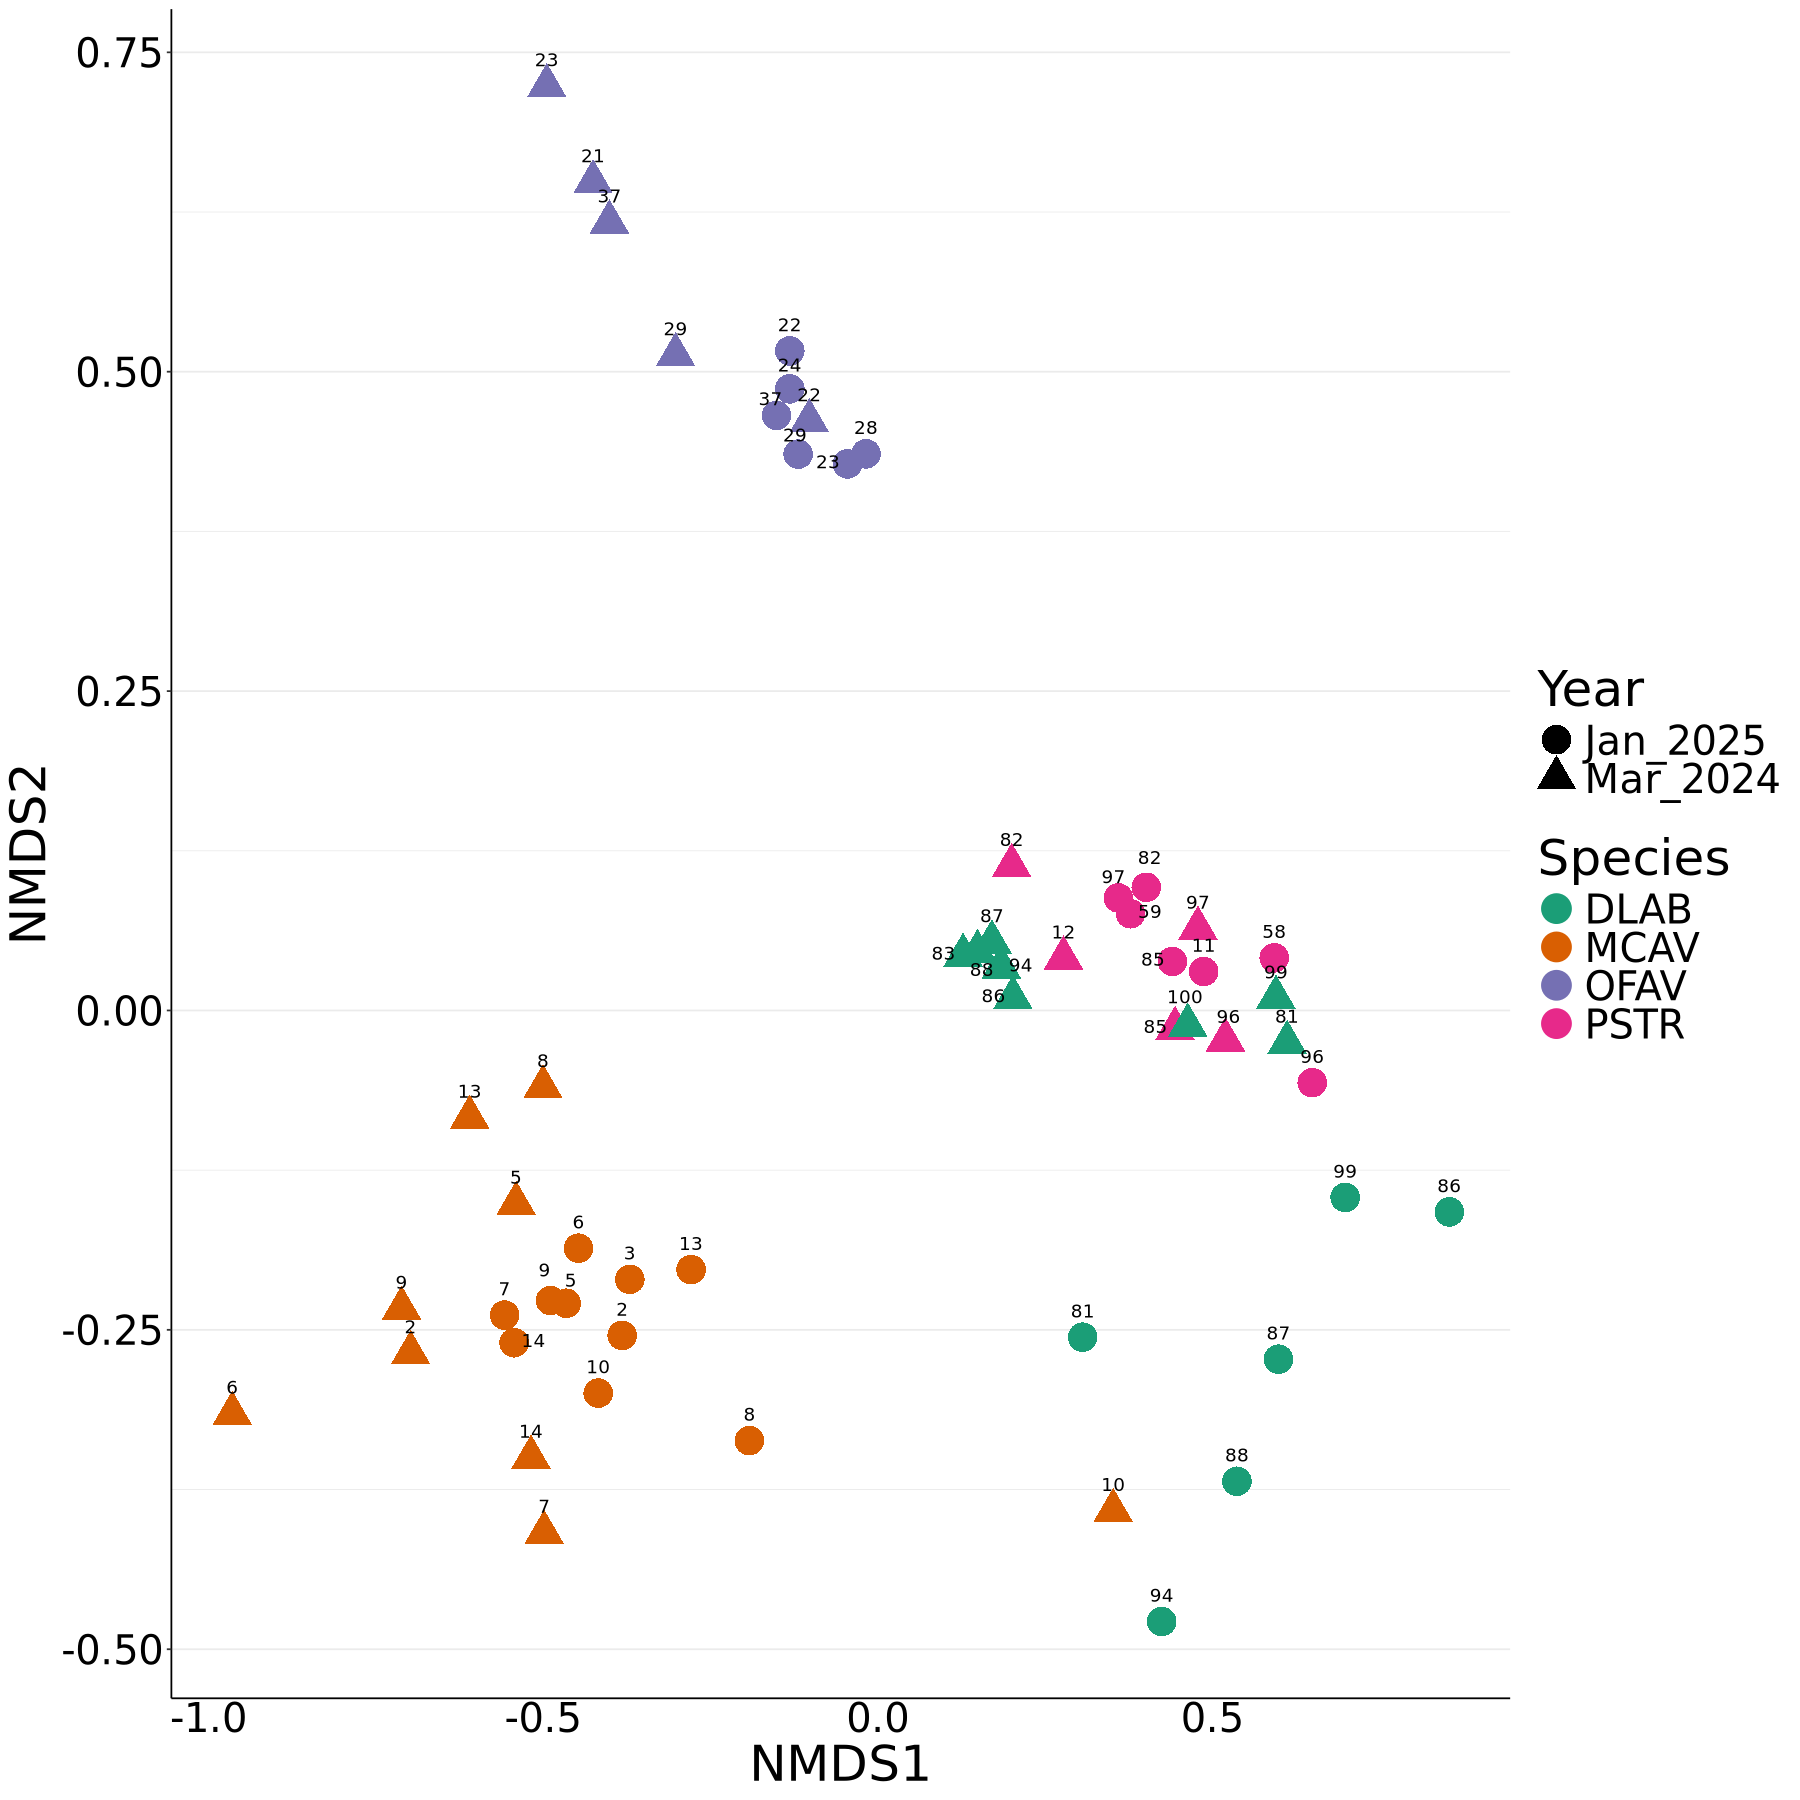

In [30]:
# visualize ordination plot
COL_all_plot <- plot_ordination(COL_all, COL_all.ord, type="Samples", color="Species", shape="Year")+
geom_point(size=8) + scale_color_brewer(palette = "Dark2")+
#geom_label(aes(label = SAMP$Tag), vjust = -1, color = "black") +
geom_text_repel(aes(label = SAMP$Tag), vjust = -1.5, color = "black", segment.color= "NA") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
COL_all_plot

In [36]:
ggsave(filename = "taxonomy_nmds.png", plot = COL_all_plot, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


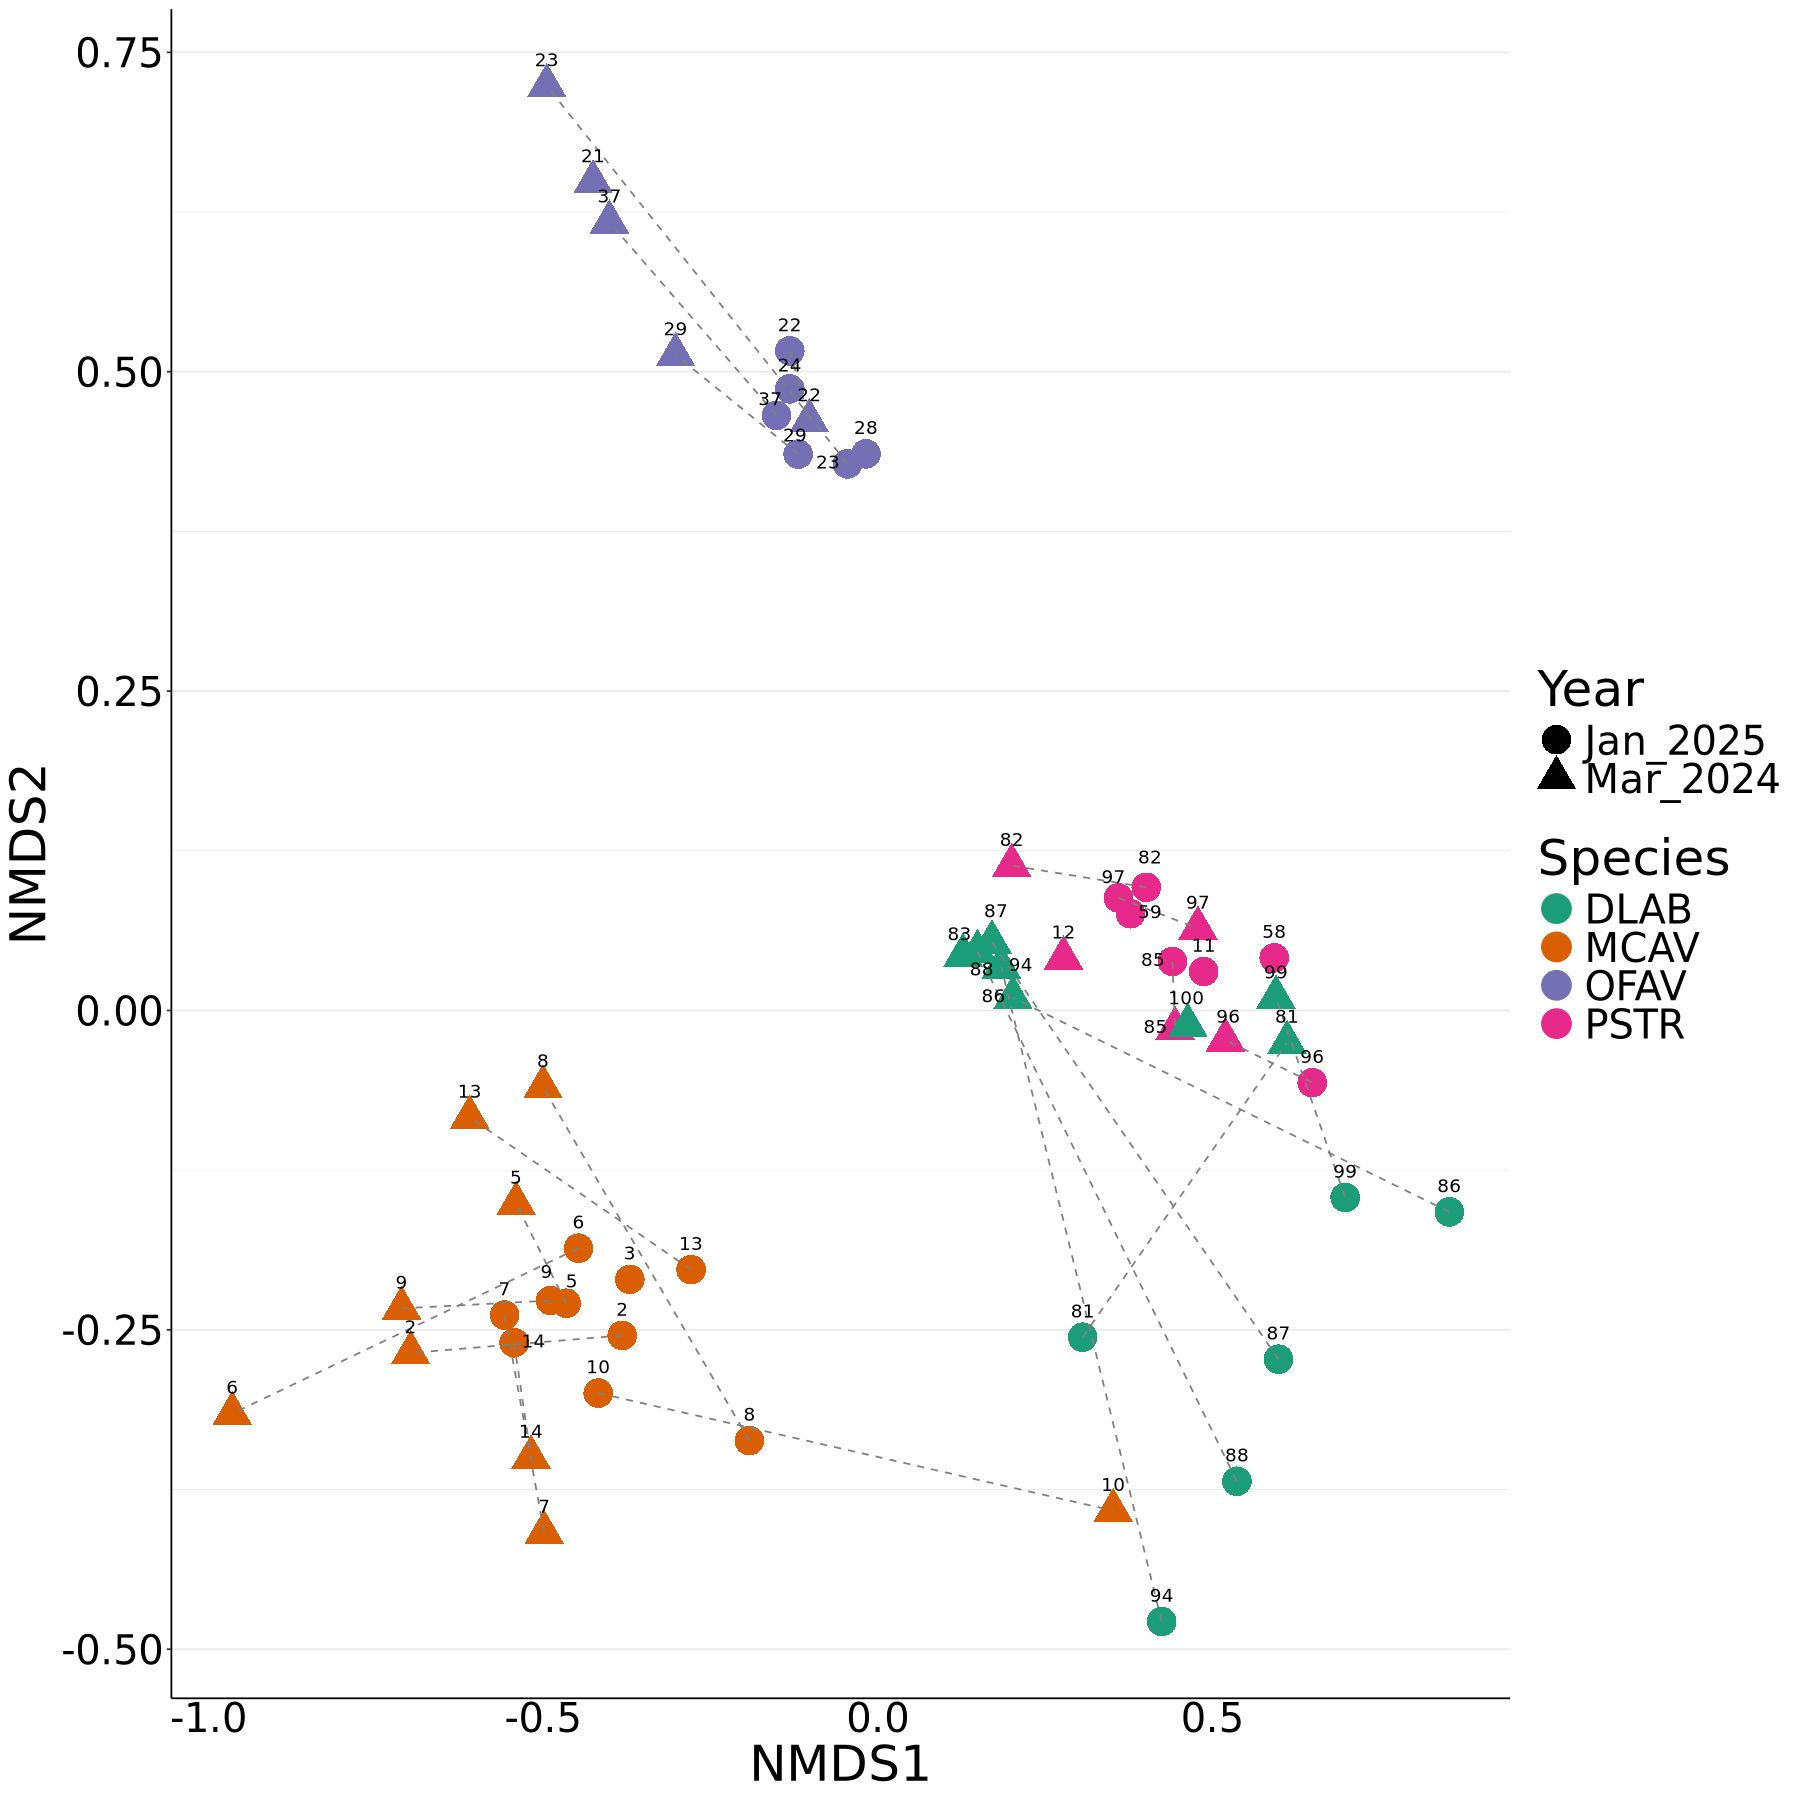

In [31]:
# visualize ordination plot with paths between years
COL_all_plot_2 <- plot_ordination(COL_all, COL_all.ord, type="Samples", color="Species", shape="Year")+
geom_point(size=8) + scale_color_brewer(palette = "Dark2")+
#geom_label(aes(label = SAMP$Tag), vjust = -1, color = "black") +
geom_path(aes(group = SAMP$Tag), color = "gray50", linetype = "dashed") +
geom_text_repel(aes(label = SAMP$Tag), vjust = -1.5, color = "black", segment.color= "NA") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
COL_all_plot_2

In [38]:
ggsave(filename = "taxonomy_nmds_w_paths.png", plot = COL_all_plot_2, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


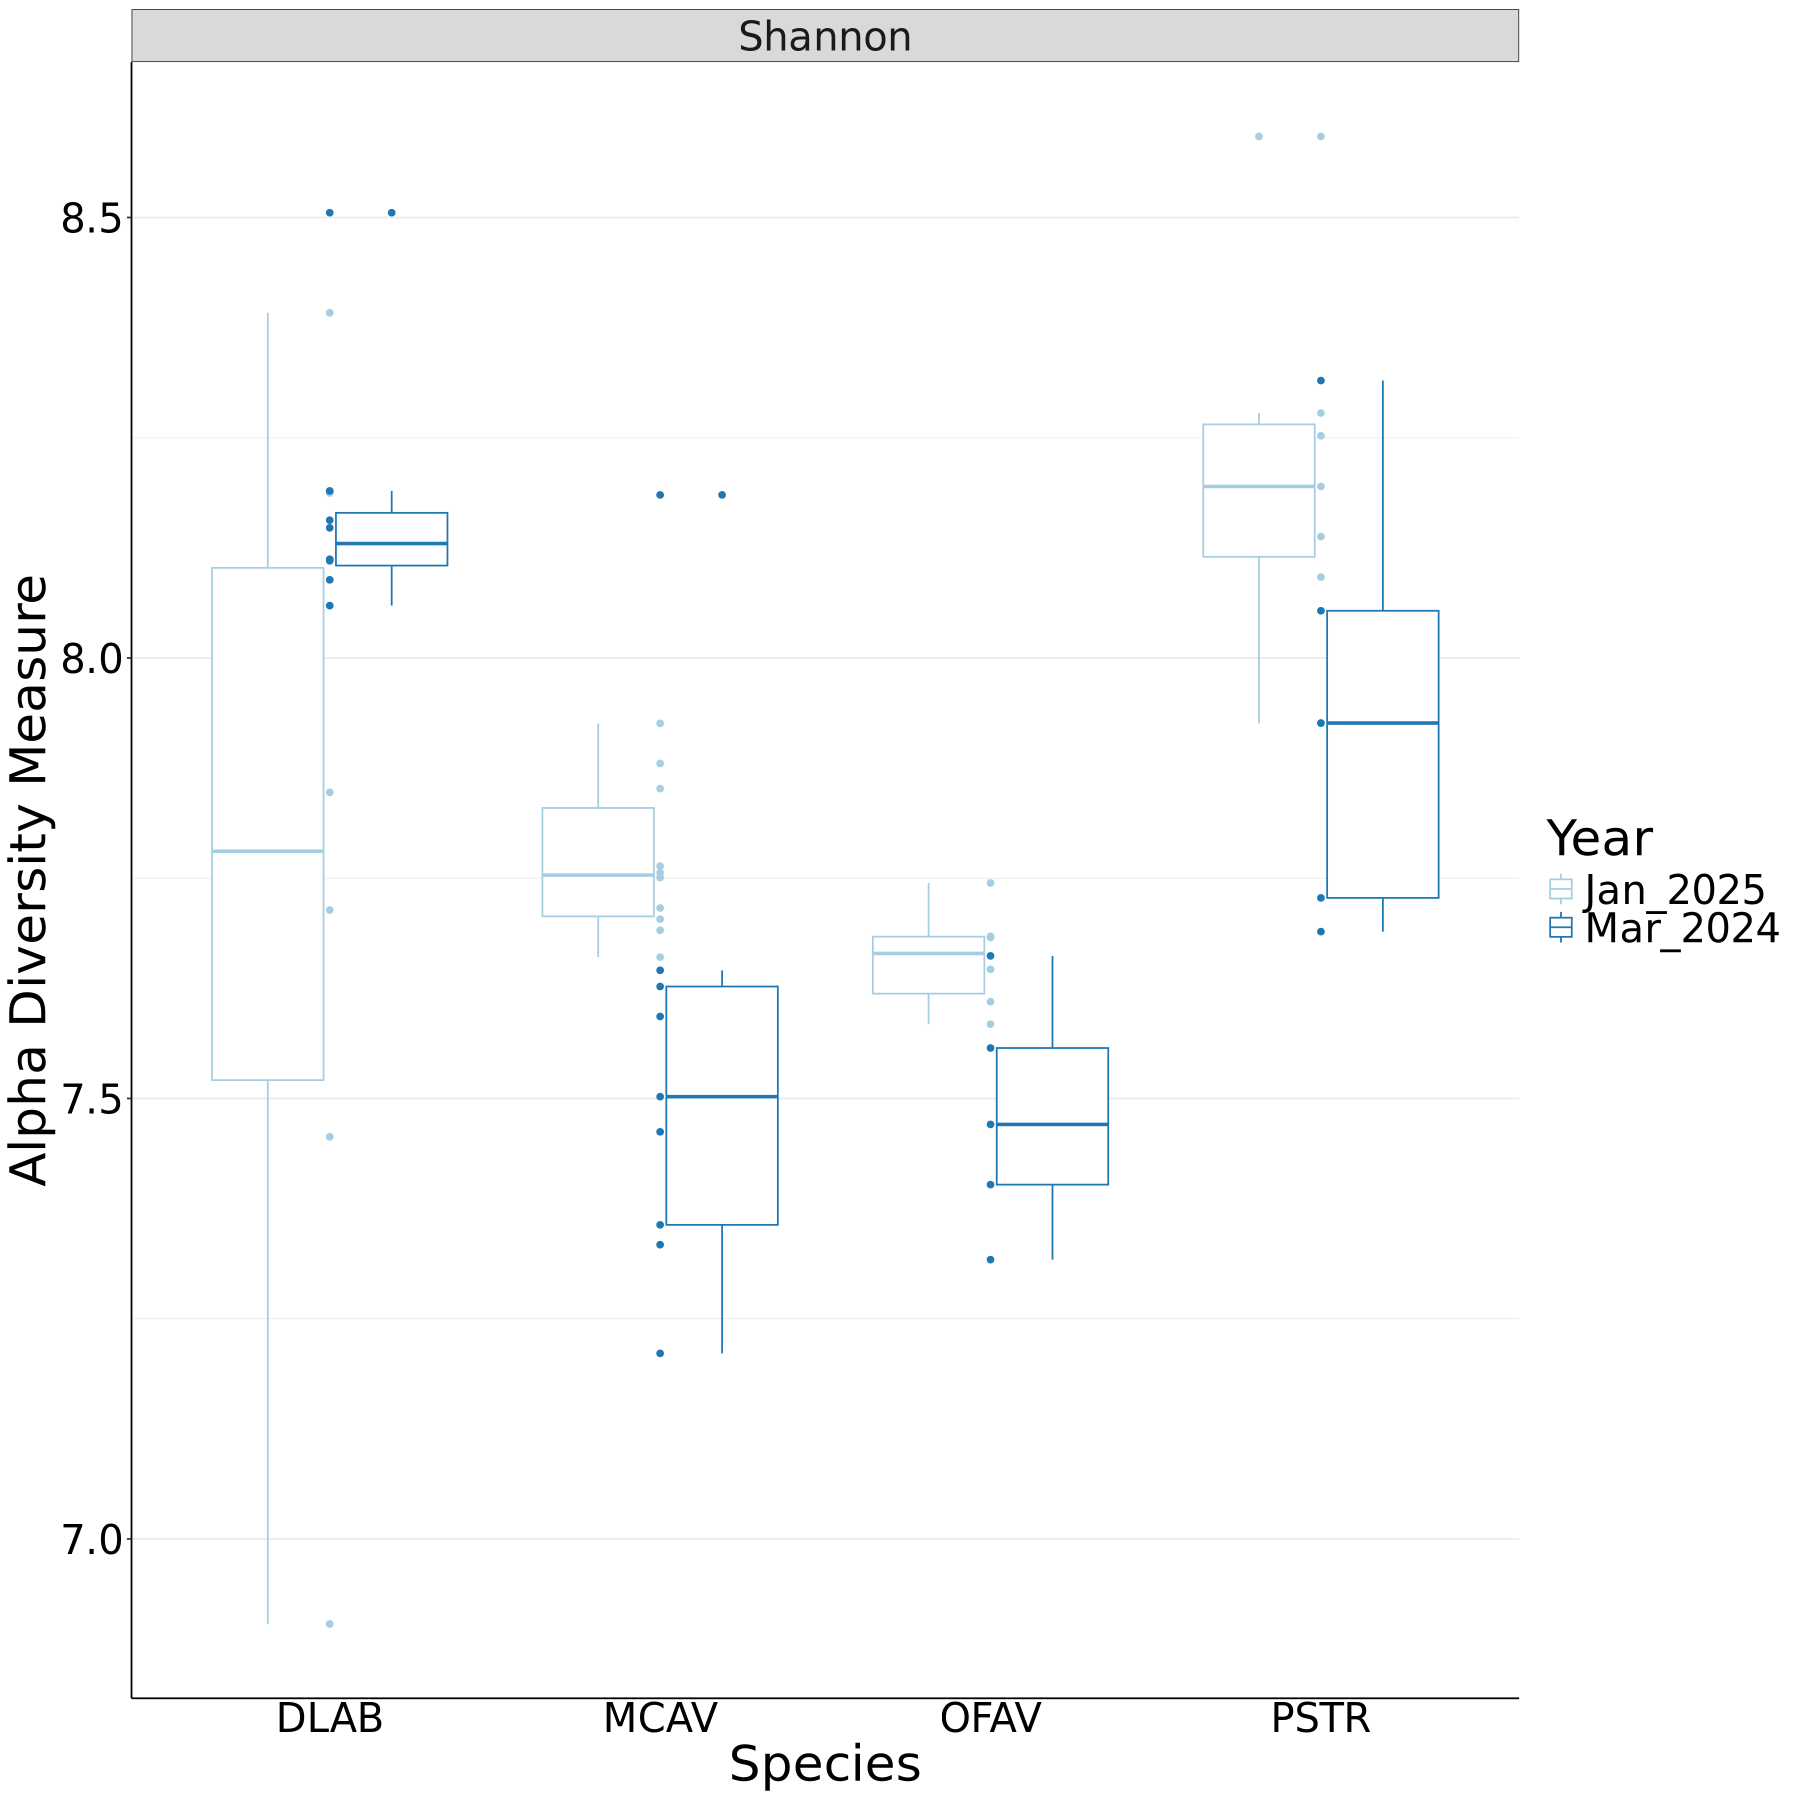

In [32]:
rich_plot <- plot_richness(COL_all, x="Species", color="Year", measures=c("Shannon")) +
geom_boxplot() +
scale_color_brewer(palette = "Paired") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
rich_plot

In [65]:
#re-ordering data to have Mar-2024 first
#year_order <- c("Mar_2024", "Jan_2025")
#SAMP$Year <- as.character(SAMP$Year)
#SAMP$Year <- factor(SAMP$Year, levels= c("Mar-24", "Jan-25"))

In [66]:
#rich_plot$COL_all$Year <- as.character(rich_plot$COL_all$Year)
#rich_plot$COL_all$Year <- factor(rich_plot$COL_all$Year, levels=year_order)
#print(rich_plot)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


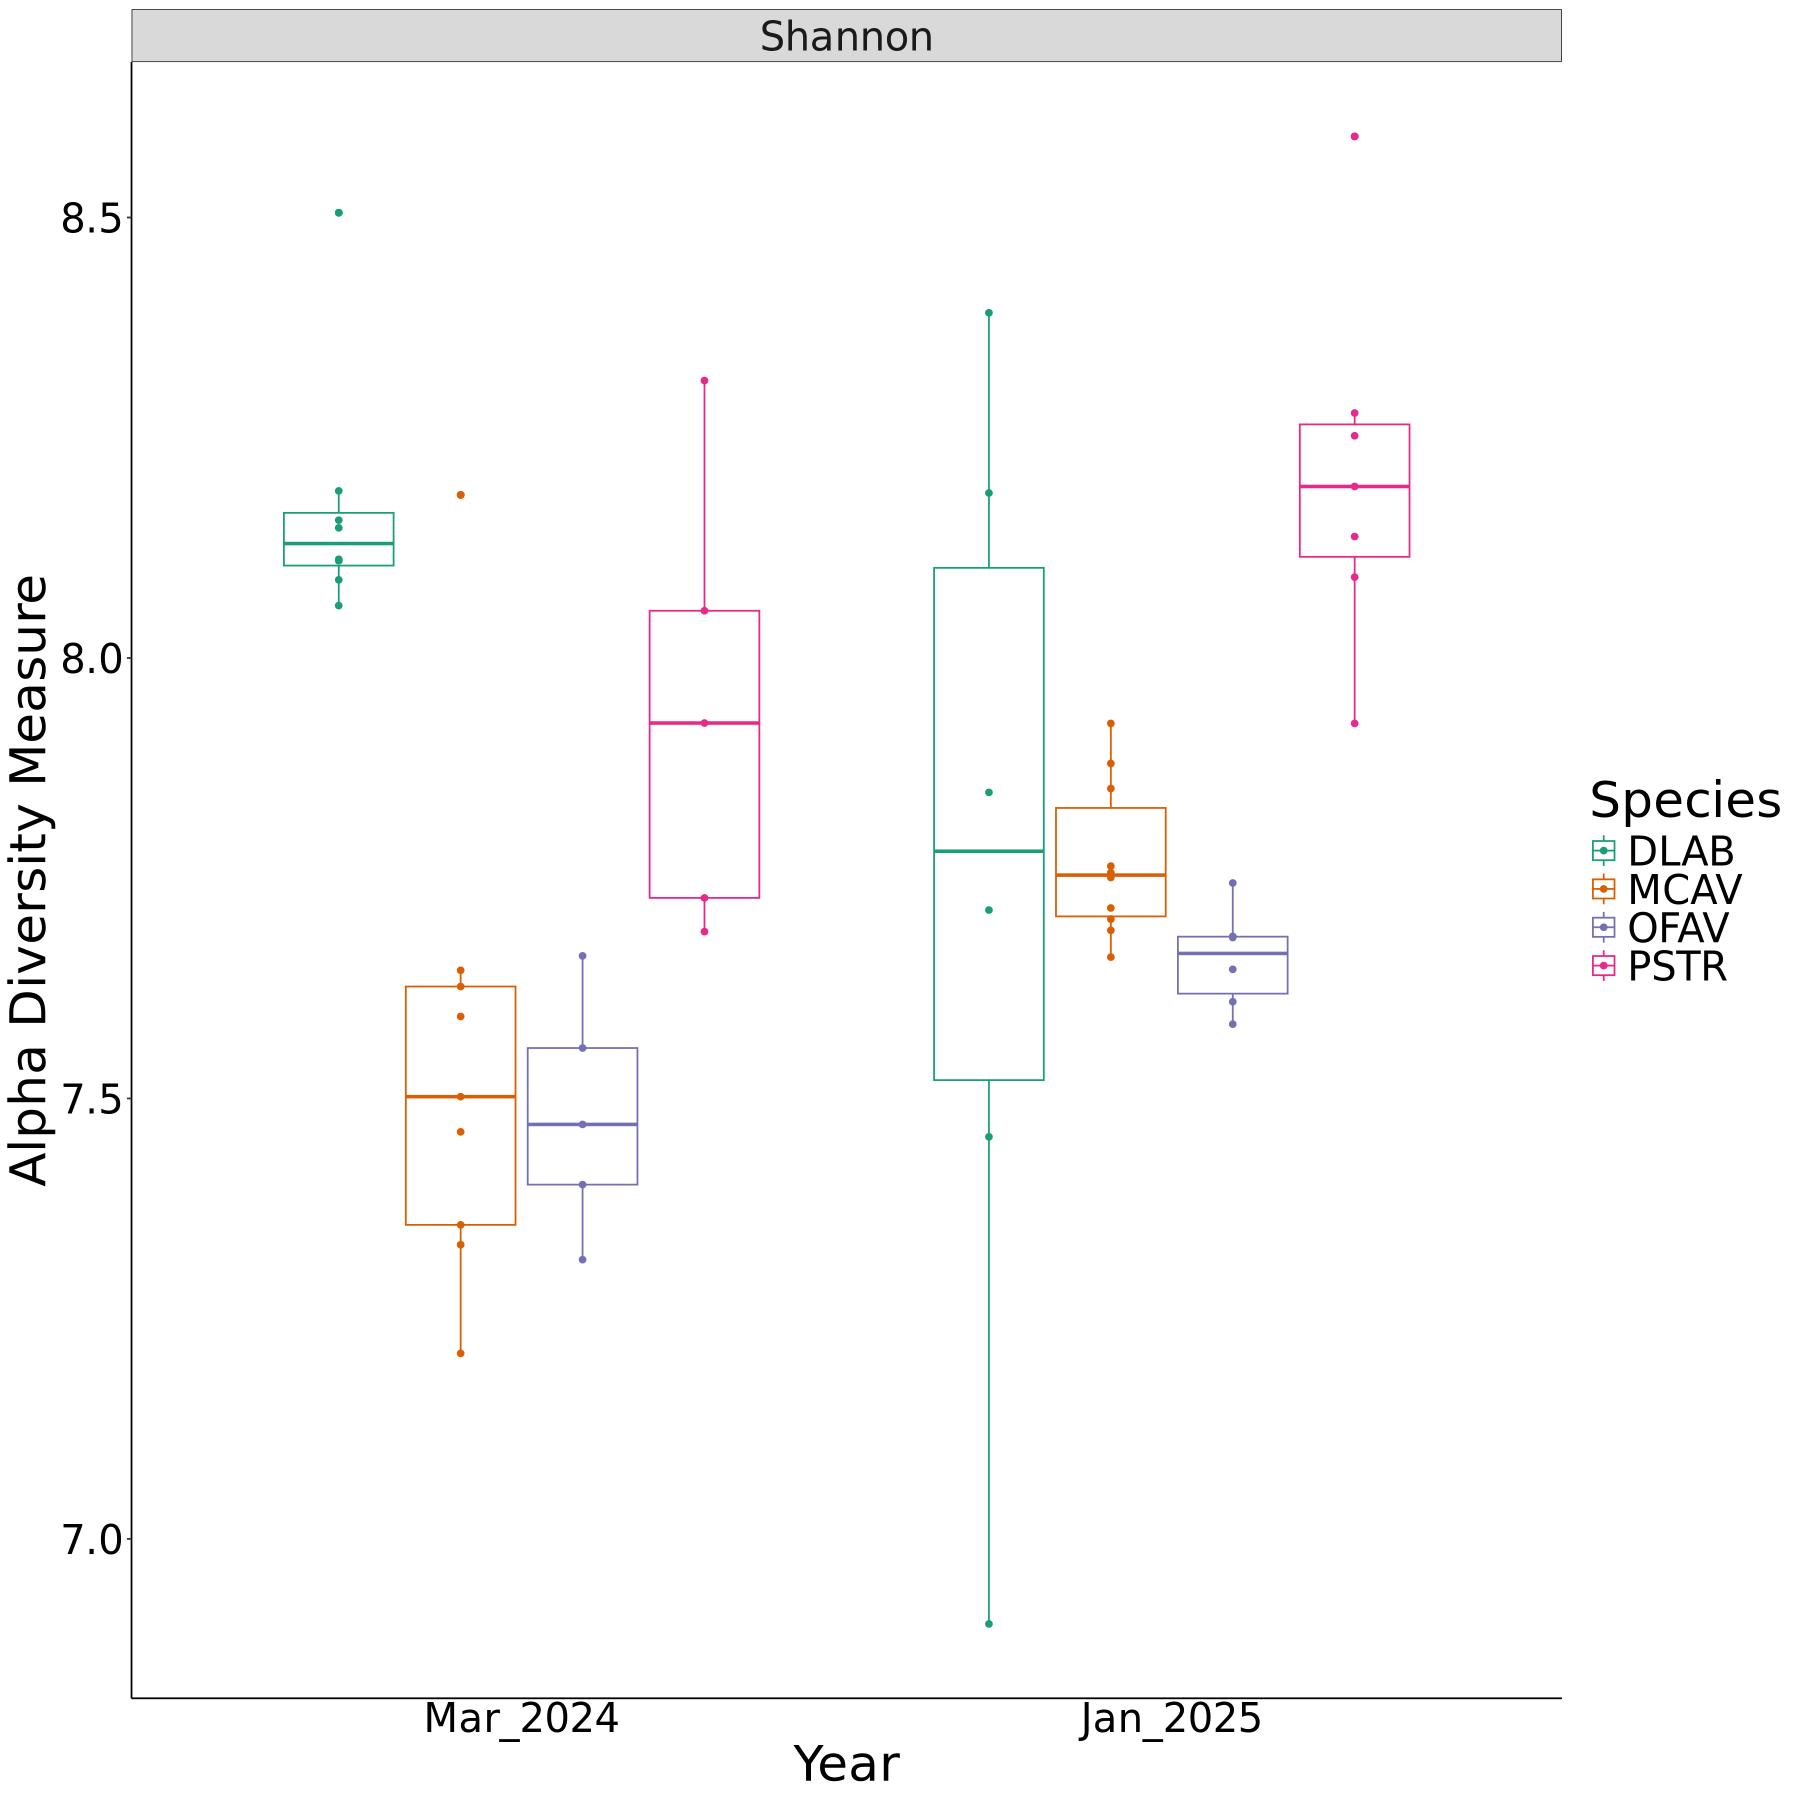

In [33]:
rich_plot_2 <- plot_richness(COL_all, x="Year", color="Species", measures=c("Shannon")) + 
geom_boxplot() +
scale_color_brewer(palette = "Dark2") +
scale_x_discrete(limits = c("Mar_2024", "Jan_2025")) +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
rich_plot_2$layers <- rich_plot_2$layers[-1]
rich_plot_2 + geom_point(position = position_dodge(width = 0.75))

In [75]:
ggsave(filename = "shannon_richness.png", plot = rich_plot_2, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

In [37]:
#calculating permanova - create distance matrix
bray_dist <- phyloseq::distance(COL_all, method = "bray")

In [38]:
metadata <- as(phyloseq::sample_data(COL_all), "data.frame")

In [39]:
permanova <- vegan::adonis2(bray_dist ~ Species + Year, data = metadata, permutations = 999)
print(permanova)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Species + Year, data = metadata, permutations = 999)
         Df SumOfSqs      R2      F Pr(>F)    
Model     4   4.4079 0.51237 13.397  0.001 ***
Residual 51   4.1952 0.48763                  
Total    55   8.6031 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [40]:
permanova_yr <- vegan::adonis2(bray_dist ~ Year, data = metadata, permutations = 999)
print(permanova_yr)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Year, data = metadata, permutations = 999)
         Df SumOfSqs      R2      F Pr(>F)  
Model     1   0.3103 0.03606 2.0204  0.043 *
Residual 54   8.2928 0.96394                
Total    55   8.6031 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [41]:
permanova_sp <- vegan::adonis2(bray_dist ~ Species, data = metadata, permutations = 999)
print(permanova_sp)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Species, data = metadata, permutations = 999)
         Df SumOfSqs      R2     F Pr(>F)    
Model     3   4.0806 0.47432 15.64  0.001 ***
Residual 52   4.5225 0.52568                 
Total    55   8.6031 1.00000                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### OFAV 

looking for most abundant taxa across both time points

In [9]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_ofav = read.csv('ofav_otu_normtable_species.csv',header=TRUE)
head(otu_ofav)

,X,X032024_COL_SAN_T5_139_OFAV_S17,X032024_COL_SAN_T5_140_OFAV_S18c,X032024_COL_SAN_T5_141_OFAV_S19,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_580_OFAV_S13,X012025_COL_SAN_T5_584_OFAV_S17,X012025_COL_SAN_T5_585_OFAV_S18,X012025_COL_SAN_T5_596_OFAV_S29
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,35481.973,26390.998,44985.741,32415.037,29103.291,29400.915,29797.218,37847.807,28849.096,30054.910,31746.959
2,28213,0.000,13547.034,0.000,0.000,0.000,13545.146,10358.983,18285.279,17532.020,11807.927,20073.312
3,573,6440.276,7420.281,3965.308,9674.105,7028.425,6432.184,3891.860,3321.993,9835.328,8428.590,6534.219
4,2721244,8874.523,5420.640,6563.269,6462.328,7145.306,5701.101,7022.727,5544.291,6226.941,5814.183,6877.763
5,238834,5690.657,4318.859,6182.365,4627.027,5789.490,5426.107,5348.016,5068.903,4514.233,5286.274,4527.918
6,28901,4578.319,2964.460,4102.043,3140.691,4963.533,4212.108,4505.394,2279.574,3419.419,2894.522,2095.622


In [10]:
# rename first col as otu
names(otu_ofav)[1] <- "otu"

#remove X's from headers
names(otu_ofav) <- sub("^X", "", names(otu_ofav))
otu_table_ofav=as.data.frame(otu_ofav)

# make the index the otus
row.names(otu_table_ofav) <- otu_table_ofav$otu
otu_table_ofav$otu <- NULL
head(otu_table_ofav)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,35481.973,26390.998,44985.741,32415.037,29103.291,29400.915,29797.218,37847.807,28849.096,30054.910,31746.959
28213,0.000,13547.034,0.000,0.000,0.000,13545.146,10358.983,18285.279,17532.020,11807.927,20073.312
573,6440.276,7420.281,3965.308,9674.105,7028.425,6432.184,3891.860,3321.993,9835.328,8428.590,6534.219
2721244,8874.523,5420.640,6563.269,6462.328,7145.306,5701.101,7022.727,5544.291,6226.941,5814.183,6877.763
238834,5690.657,4318.859,6182.365,4627.027,5789.490,5426.107,5348.016,5068.903,4514.233,5286.274,4527.918
28901,4578.319,2964.460,4102.043,3140.691,4963.533,4212.108,4505.394,2279.574,3419.419,2894.522,2095.622


In [11]:
# sort by most abundant OTUs
otus_sorted_ofav <- otu_table_ofav[order(rowSums(otu_table_ofav), decreasing = TRUE), ]
head(otus_sorted_ofav)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,124063.000,328559.000,102388.000,154743.000,128336.000,298188.000,379767.000,349188.000,333390.000,278457.000,291083.000
562,35481.973,26390.998,44985.741,32415.037,29103.291,29400.915,29797.218,37847.807,28849.096,30054.910,31746.959
28213,0.000,13547.034,0.000,0.000,0.000,13545.146,10358.983,18285.279,17532.020,11807.927,20073.312
573,6440.276,7420.281,3965.308,9674.105,7028.425,6432.184,3891.860,3321.993,9835.328,8428.590,6534.219
2721244,8874.523,5420.640,6563.269,6462.328,7145.306,5701.101,7022.727,5544.291,6226.941,5814.183,6877.763
238834,5690.657,4318.859,6182.365,4627.027,5789.490,5426.107,5348.016,5068.903,4514.233,5286.274,4527.918


In [12]:
#remove total reads row
otus_sorted_ofav <- otus_sorted_ofav[-1, ]
head(otus_sorted_ofav)
dim (otus_sorted_ofav)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,35481.973,26390.998,44985.741,32415.037,29103.291,29400.915,29797.218,37847.807,28849.096,30054.910,31746.959
28213,0.000,13547.034,0.000,0.000,0.000,13545.146,10358.983,18285.279,17532.020,11807.927,20073.312
573,6440.276,7420.281,3965.308,9674.105,7028.425,6432.184,3891.860,3321.993,9835.328,8428.590,6534.219
2721244,8874.523,5420.640,6563.269,6462.328,7145.306,5701.101,7022.727,5544.291,6226.941,5814.183,6877.763
238834,5690.657,4318.859,6182.365,4627.027,5789.490,5426.107,5348.016,5068.903,4514.233,5286.274,4527.918
2057741,2845.329,9033.385,4355.979,2785.263,3194.739,2796.893,2196.083,5392.511,6007.979,2560.539,9681.088


[1] 13367    11

In [13]:
#remove Sum column
otus_sorted_ofav$Sum <- NULL
head(otus_sorted_ofav)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,35481.973,26390.998,44985.741,32415.037,29103.291,29400.915,29797.218,37847.807,28849.096,30054.910,31746.959
28213,0.000,13547.034,0.000,0.000,0.000,13545.146,10358.983,18285.279,17532.020,11807.927,20073.312
573,6440.276,7420.281,3965.308,9674.105,7028.425,6432.184,3891.860,3321.993,9835.328,8428.590,6534.219
2721244,8874.523,5420.640,6563.269,6462.328,7145.306,5701.101,7022.727,5544.291,6226.941,5814.183,6877.763
238834,5690.657,4318.859,6182.365,4627.027,5789.490,5426.107,5348.016,5068.903,4514.233,5286.274,4527.918
2057741,2845.329,9033.385,4355.979,2785.263,3194.739,2796.893,2196.083,5392.511,6007.979,2560.539,9681.088


In [14]:
# Convert to matrix
otus_ofav=as.matrix(otus_sorted_ofav)
head(otus_ofav)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29
562,35481.973,26390.998,44985.741,32415.037,29103.291,29400.915,29797.218,37847.807,28849.096,30054.910,31746.959
28213,0.000,13547.034,0.000,0.000,0.000,13545.146,10358.983,18285.279,17532.020,11807.927,20073.312
573,6440.276,7420.281,3965.308,9674.105,7028.425,6432.184,3891.860,3321.993,9835.328,8428.590,6534.219
2721244,8874.523,5420.640,6563.269,6462.328,7145.306,5701.101,7022.727,5544.291,6226.941,5814.183,6877.763
238834,5690.657,4318.859,6182.365,4627.027,5789.490,5426.107,5348.016,5068.903,4514.233,5286.274,4527.918
2057741,2845.329,9033.385,4355.979,2785.263,3194.739,2796.893,2196.083,5392.511,6007.979,2560.539,9681.088


In [17]:
#filter metadata for ofavs only
metadata_ofav <- metadata[metadata$Species=="OFAV",]
head(metadata_ofav)
dim(metadata_ofav)

,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,OFAV,Healthy,Healthy,,,
012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,OFAV,Healthy,Healthy,Y-2025,,


[1] 11 10

In [18]:
# classify phyloseq objects 
OTU_O=otu_table((otus_ofav), taxa_are_rows = TRUE)
TAX_O=tax_table(taxonomy)
SAMP_O=sample_data(metadata_ofav)

In [19]:
# Create phyloseq object
COL_ofav = phyloseq(OTU_O, SAMP_O, TAX_O)
COL_ofav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13367 taxa and 11 samples ]
sample_data() Sample Data:       [ 11 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 13367 taxa by 1 taxonomic ranks ]

In [20]:
COL_ofav_10 = prune_taxa(names(sort(taxa_sums(COL_ofav),TRUE)[1:10]), COL_ofav)
#if I want to make it normalized to 100, can do that but for right now just looking a absolute (following normalization)

In [27]:
#order of facets
sample_data(COL_ofav_10)$Year_o <- factor(sample_data(COL_ofav_10)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

In [25]:
options(repr.plot.width=15, repr.plot.height=15)

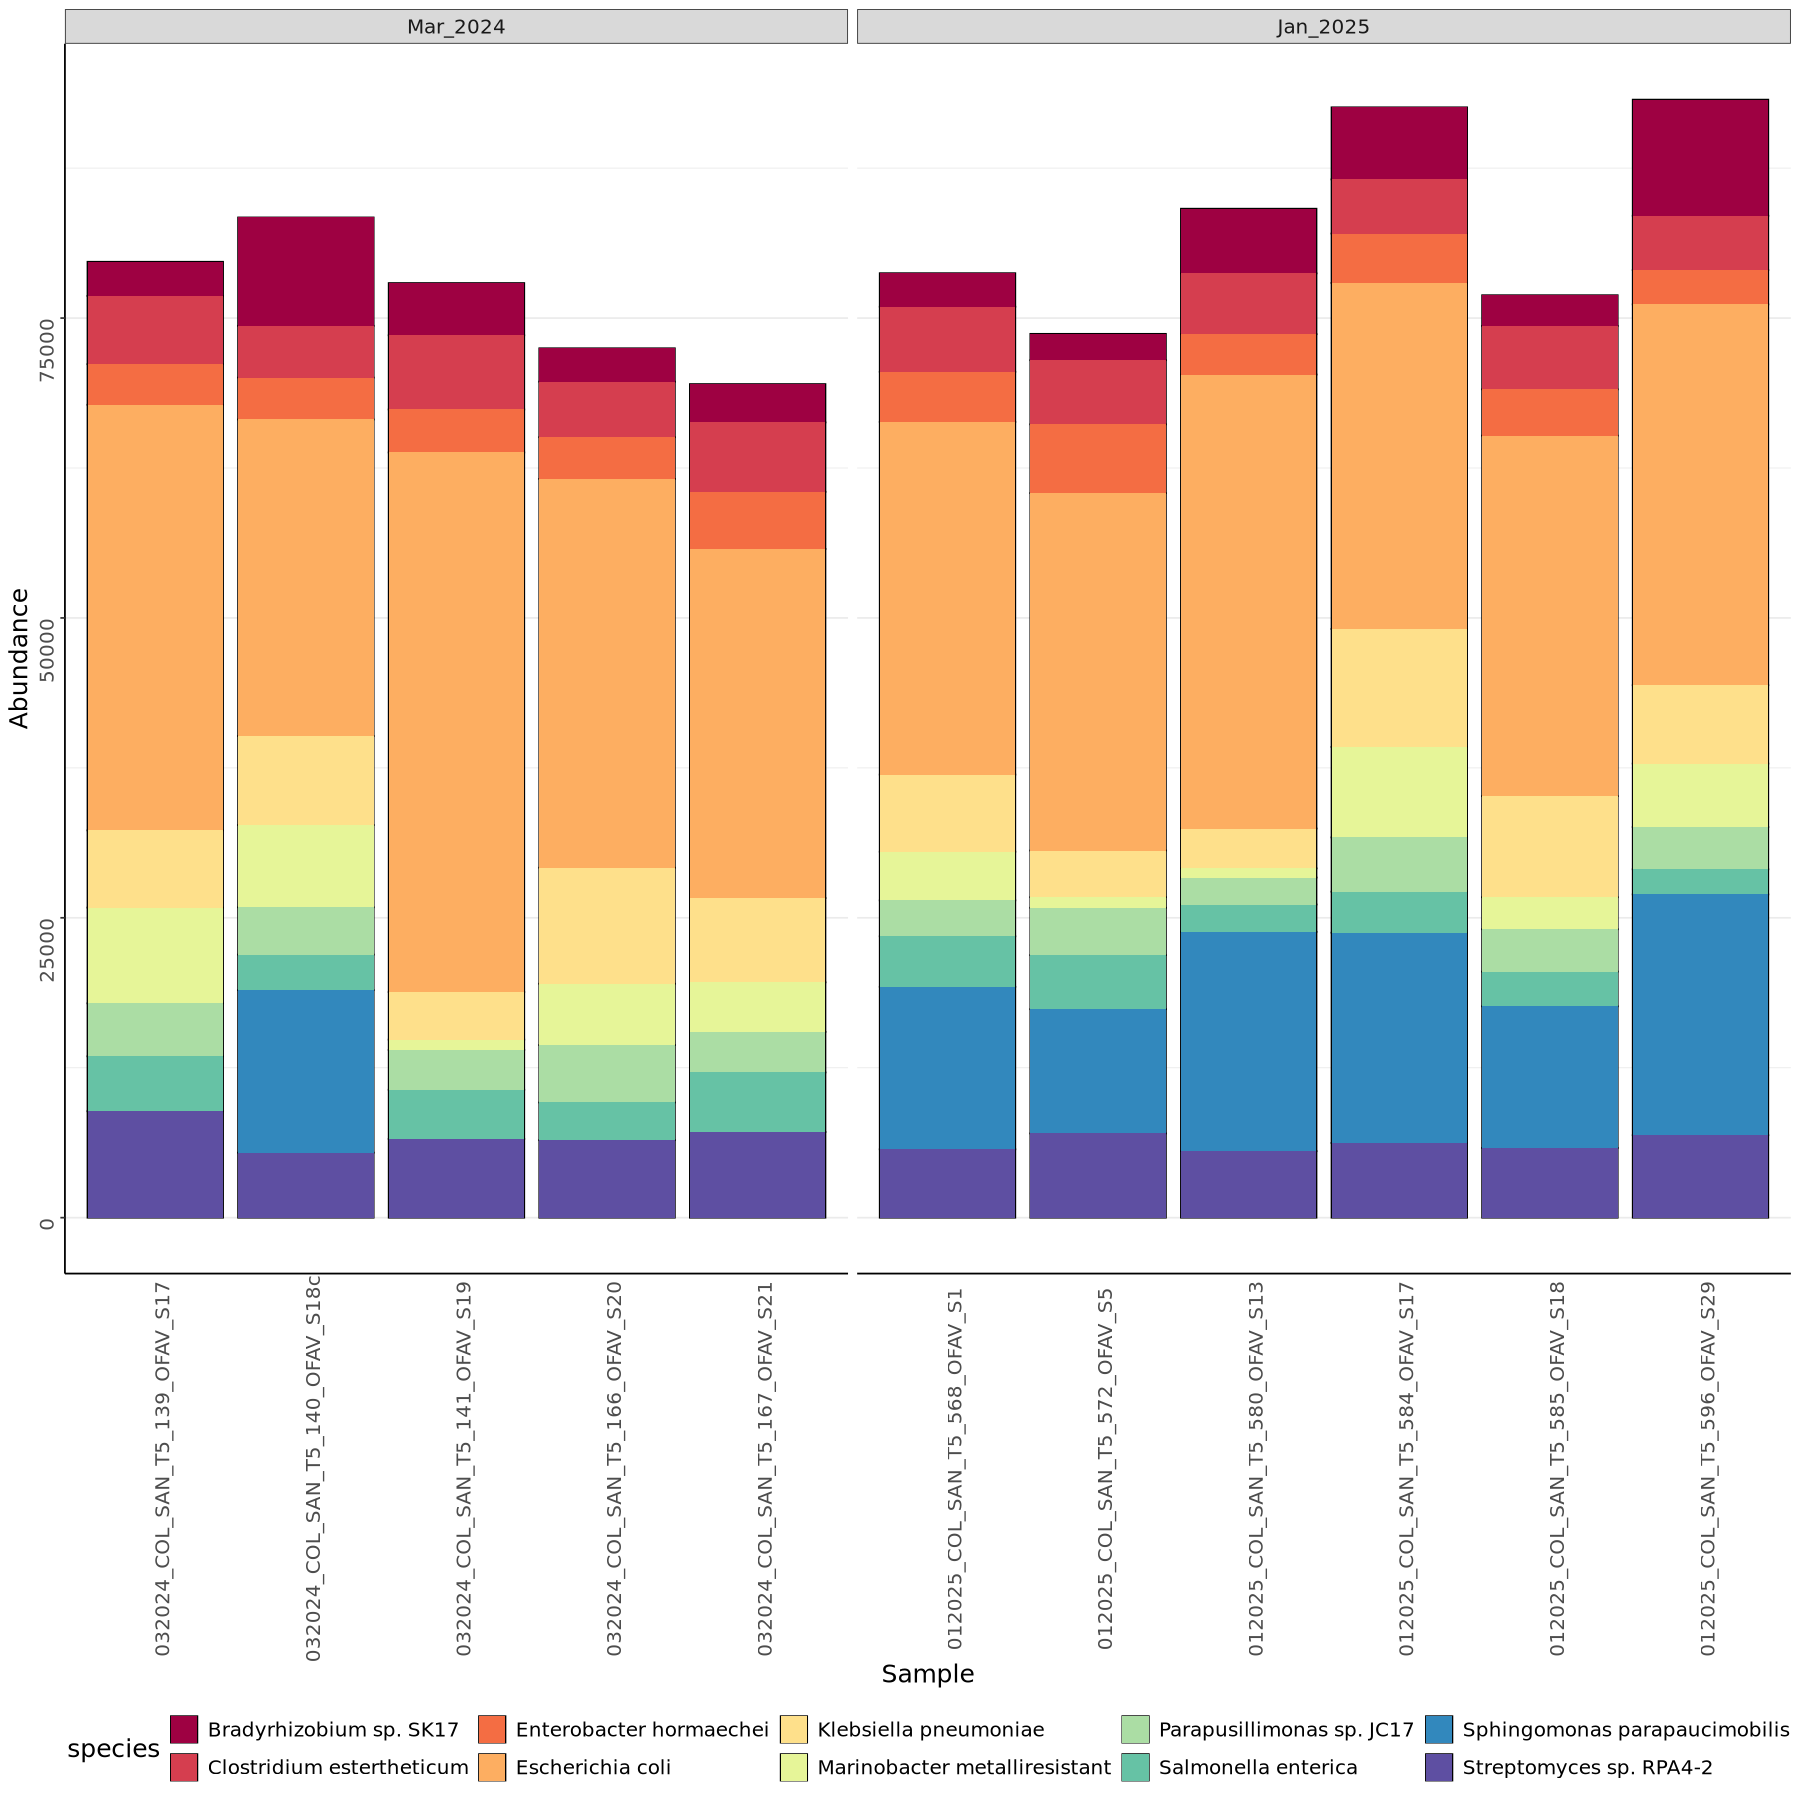

In [28]:
# bar plot of top 10 abundant taxa in OFAV samples
ofav_10_bar<-plot_bar(COL_ofav_10,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_10_bar

Relative abundance plot

In [38]:
ggsave(filename = "ofav_top_10_species_bar.png", plot = ofav_10_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

In [29]:
COL_ofav_10_rel <- transform_sample_counts(COL_ofav_10, function(x) x / sum(x))

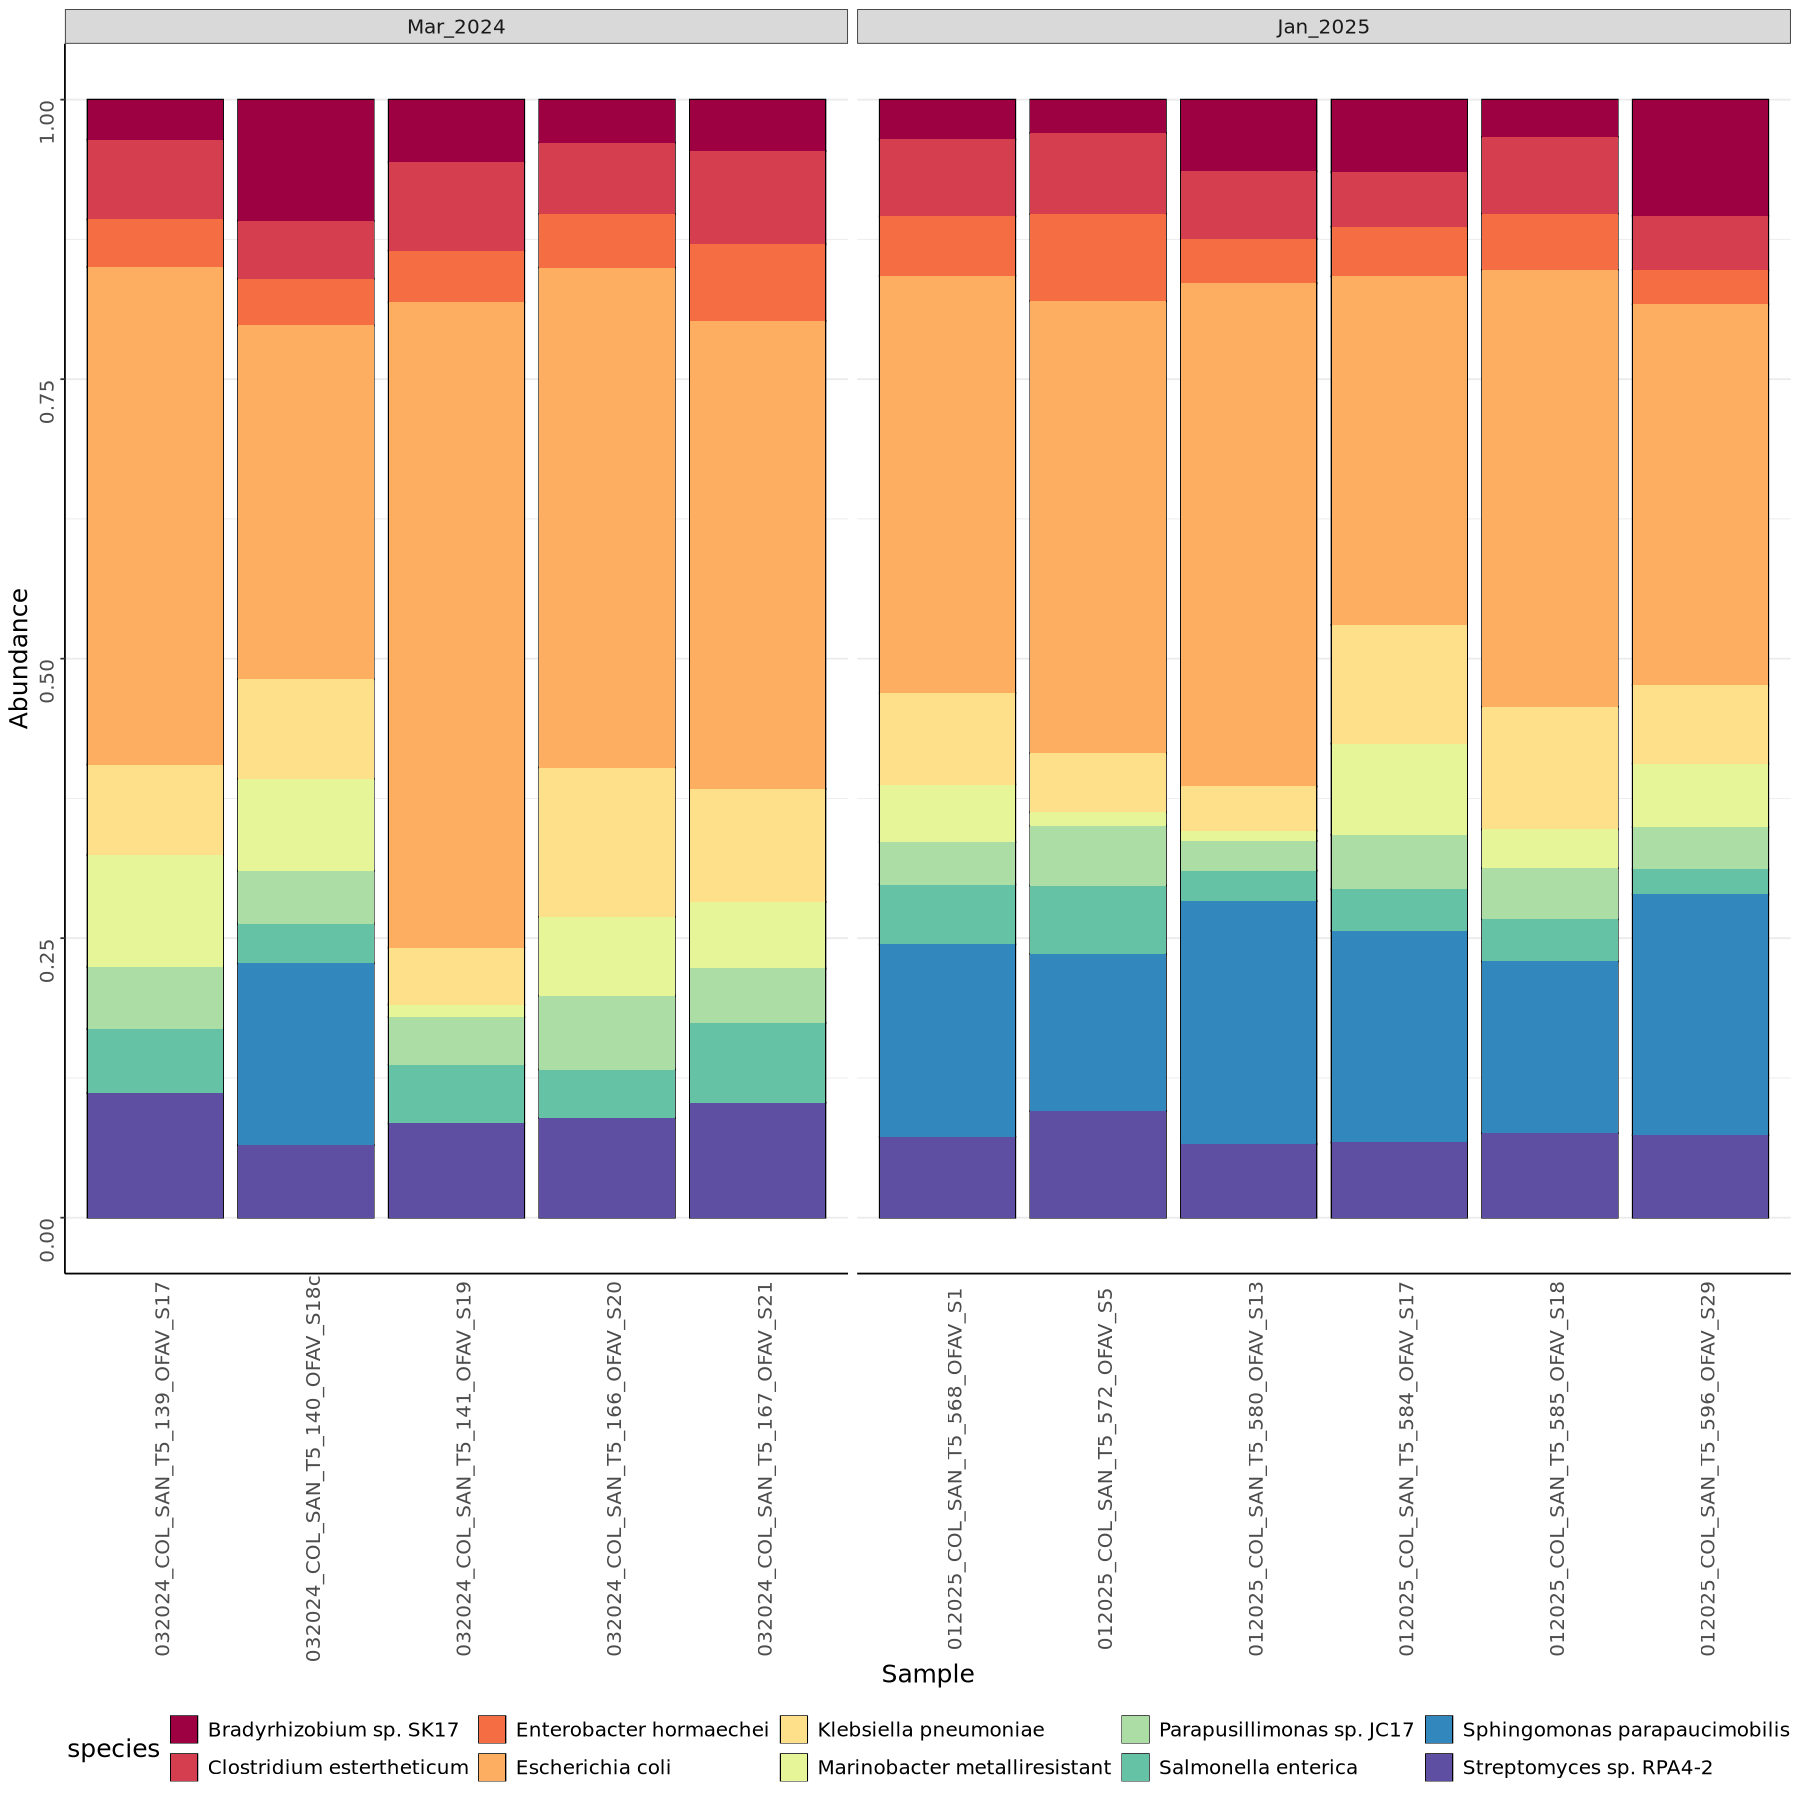

In [30]:
# bar plot of top 10 abundant taxa in OFAV samples
ofav_10_rel_bar<-plot_bar(COL_ofav_10_rel,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_10_rel_bar

Top 50 taxa

In [39]:
ggsave(filename = "ofav_top_10_species_rel_bar.png", plot = ofav_10_rel_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

In [31]:
#now do top 50
COL_ofav_50 = prune_taxa(names(sort(taxa_sums(COL_ofav),TRUE)[1:50]), COL_ofav)

In [32]:
sample_data(COL_ofav_50)$Year_o <- factor(sample_data(COL_ofav_50)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

In [33]:
#from rampgenerator.com 
colors_50 <- c("#A6CEE3",
  "#88BBD8",
  "#69A7CE",
  "#4B94C3",
  "#2D81B9",
  "#3185AF",
  "#529CA5",
  "#73B39C",
  "#94CA93",
  "#AFDE88",
  "#93D073",
  "#76C15E",
  "#5AB349",
  "#3DA534",
  "#509F3C",
  "#7C9E54",
  "#A99C6D",
  "#D69B85",
  "#FA9594",
  "#F57878",
  "#EF5B5C",
  "#EA3F40",
  "#E42224",
  "#E7352A",
  "#ED5A3C",
  "#F37F4F",
  "#F9A461",
  "#FDBB68",
  "#FEAD4F",
  "#FE9E36",
  "#FE901D",
  "#FF8205",
  "#F58827",
  "#E99457",
  "#DD9F87",
  "#D2ABB7",
  "#C2A8D1",
  "#AD8EC4",
  "#9774B6",
  "#825AA9",
  "#6C3F9B",
  "#88659A",
  "#AA909A",
  "#CBBC99",
  "#EDE799",
  "#F7EE8D",
  "#E6C974",
  "#D4A45B",
  "#C37E41",
  "#B15928")

In [34]:
options(repr.plot.width=20, repr.plot.height=15)

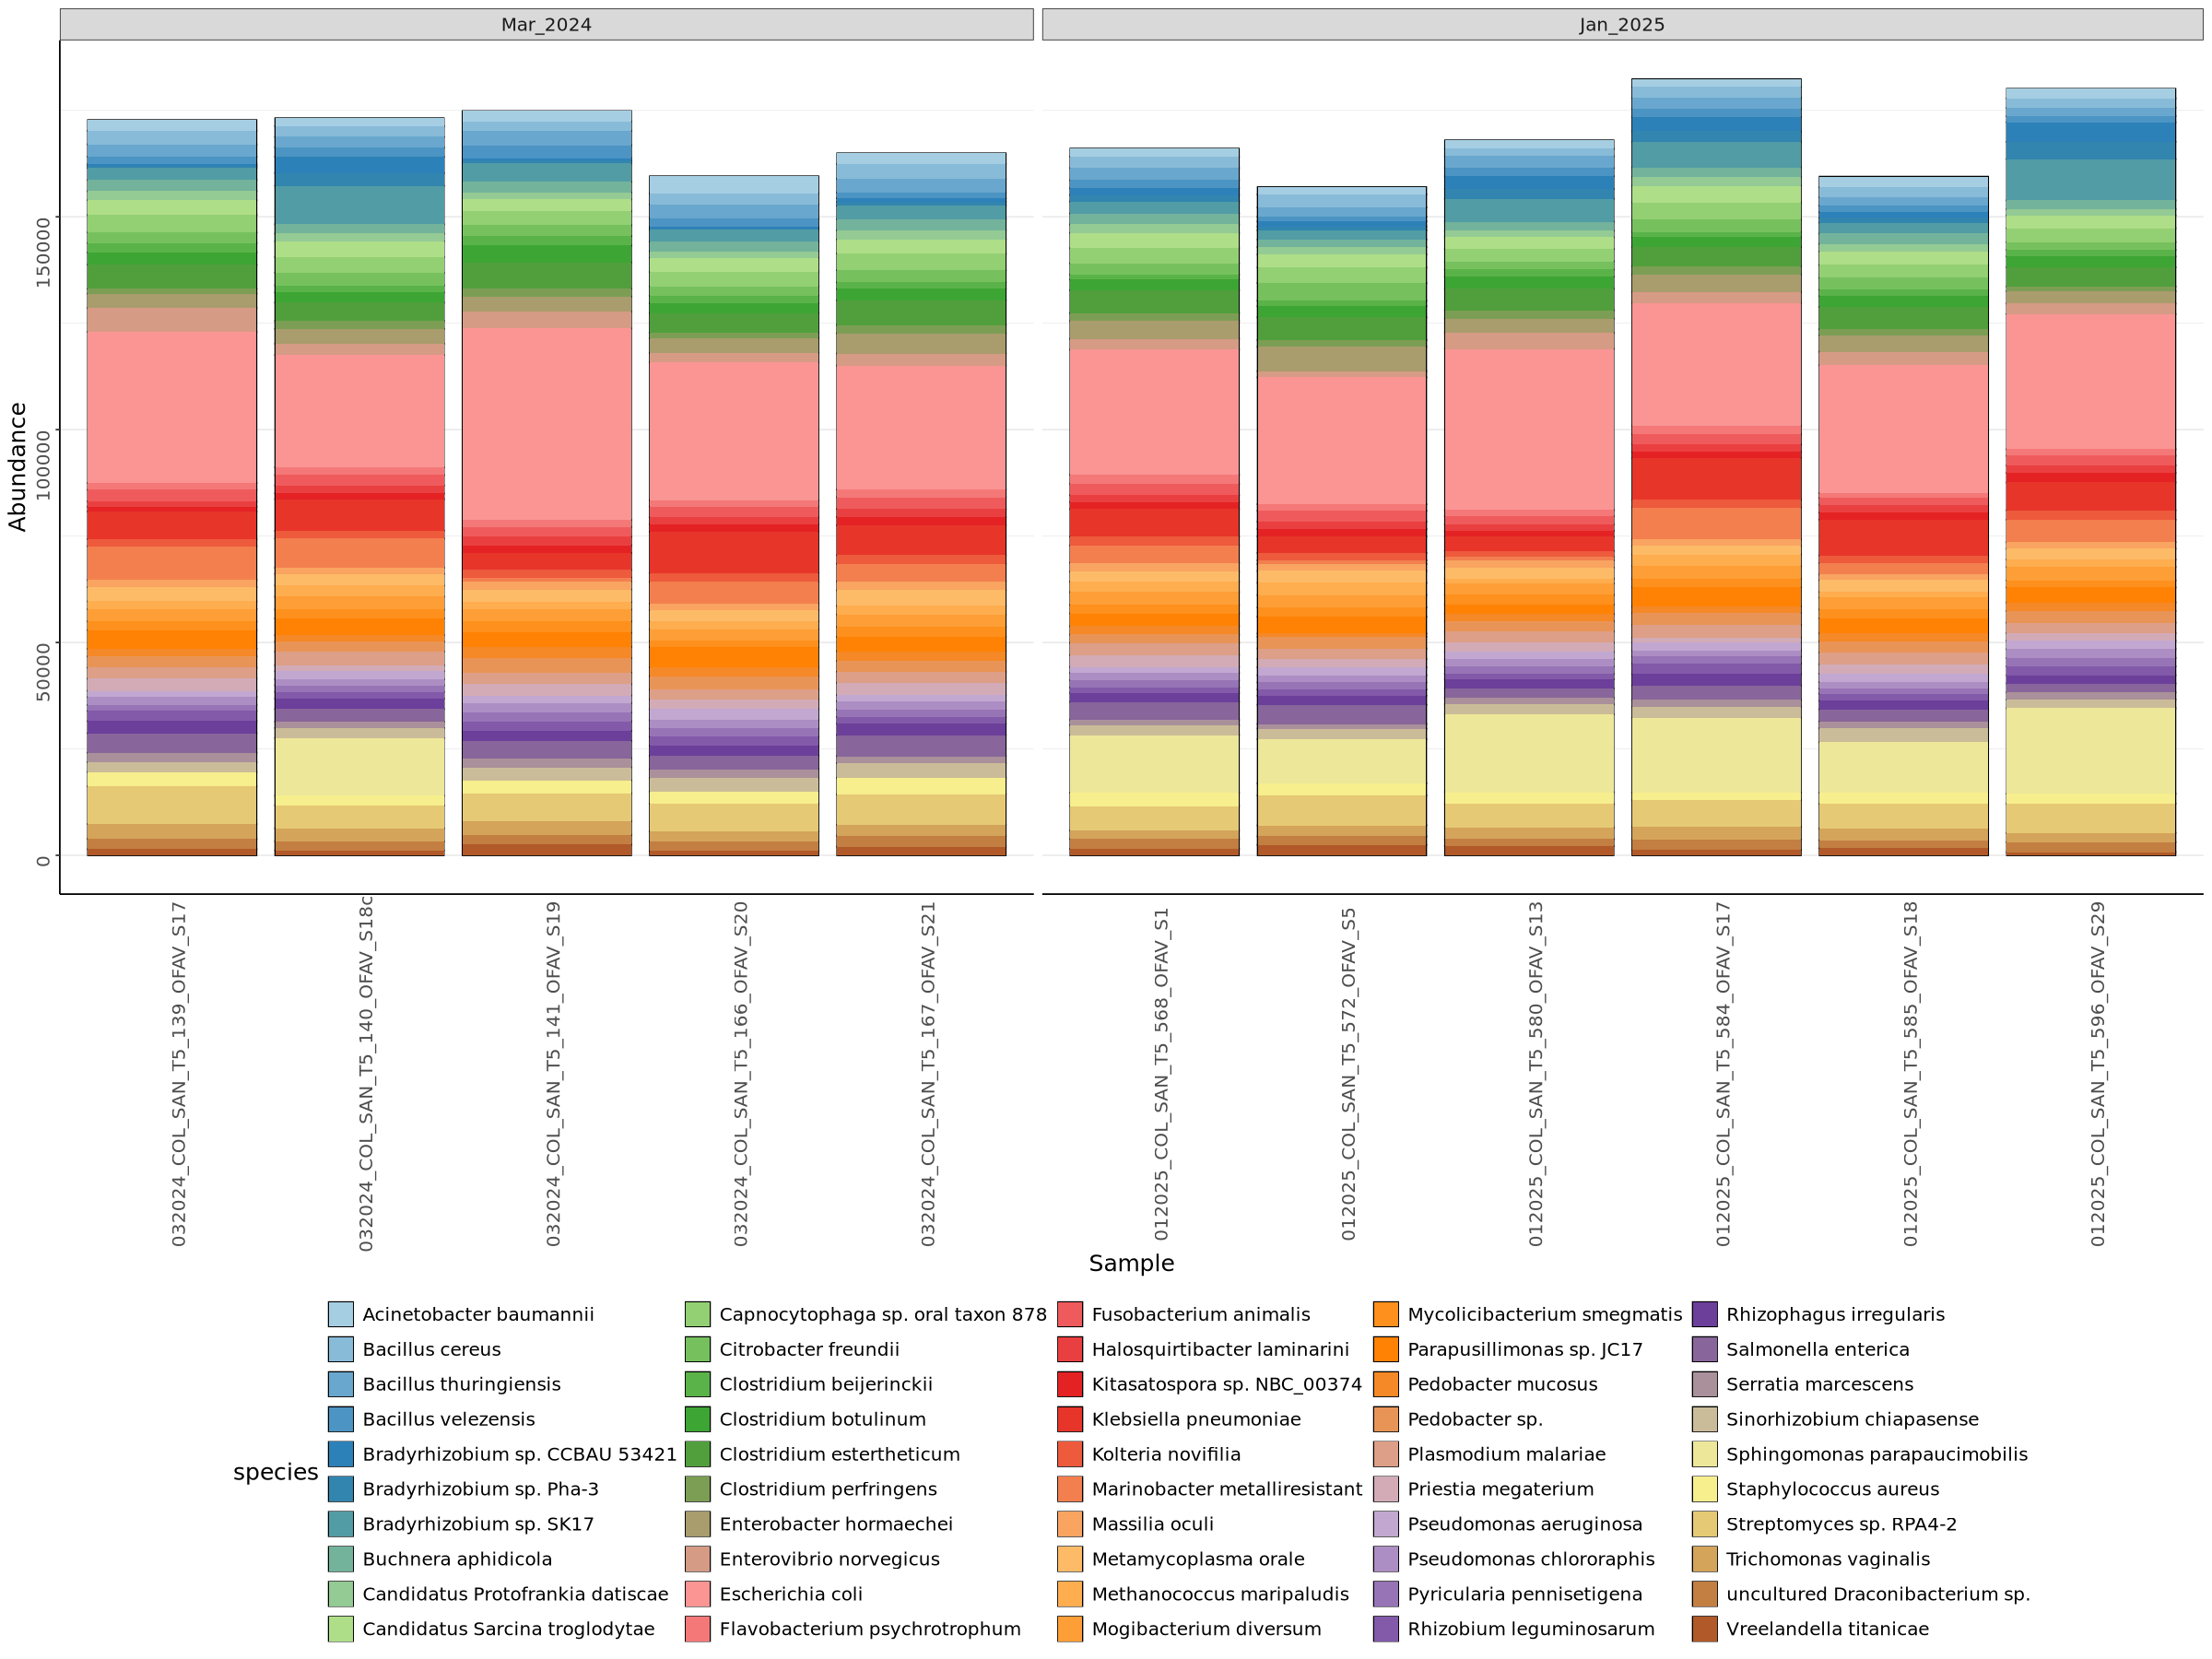

In [35]:
# bar plot of top 50 abundant taxa in OFAV samples
ofav_50_bar<-plot_bar(COL_ofav_50,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values = colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_50_bar

In [40]:
ggsave(filename = "ofav_top_50_species_bar.png", plot = ofav_50_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

In [36]:
COL_ofav_50_rel <- transform_sample_counts(COL_ofav_50, function(x) x / sum(x))

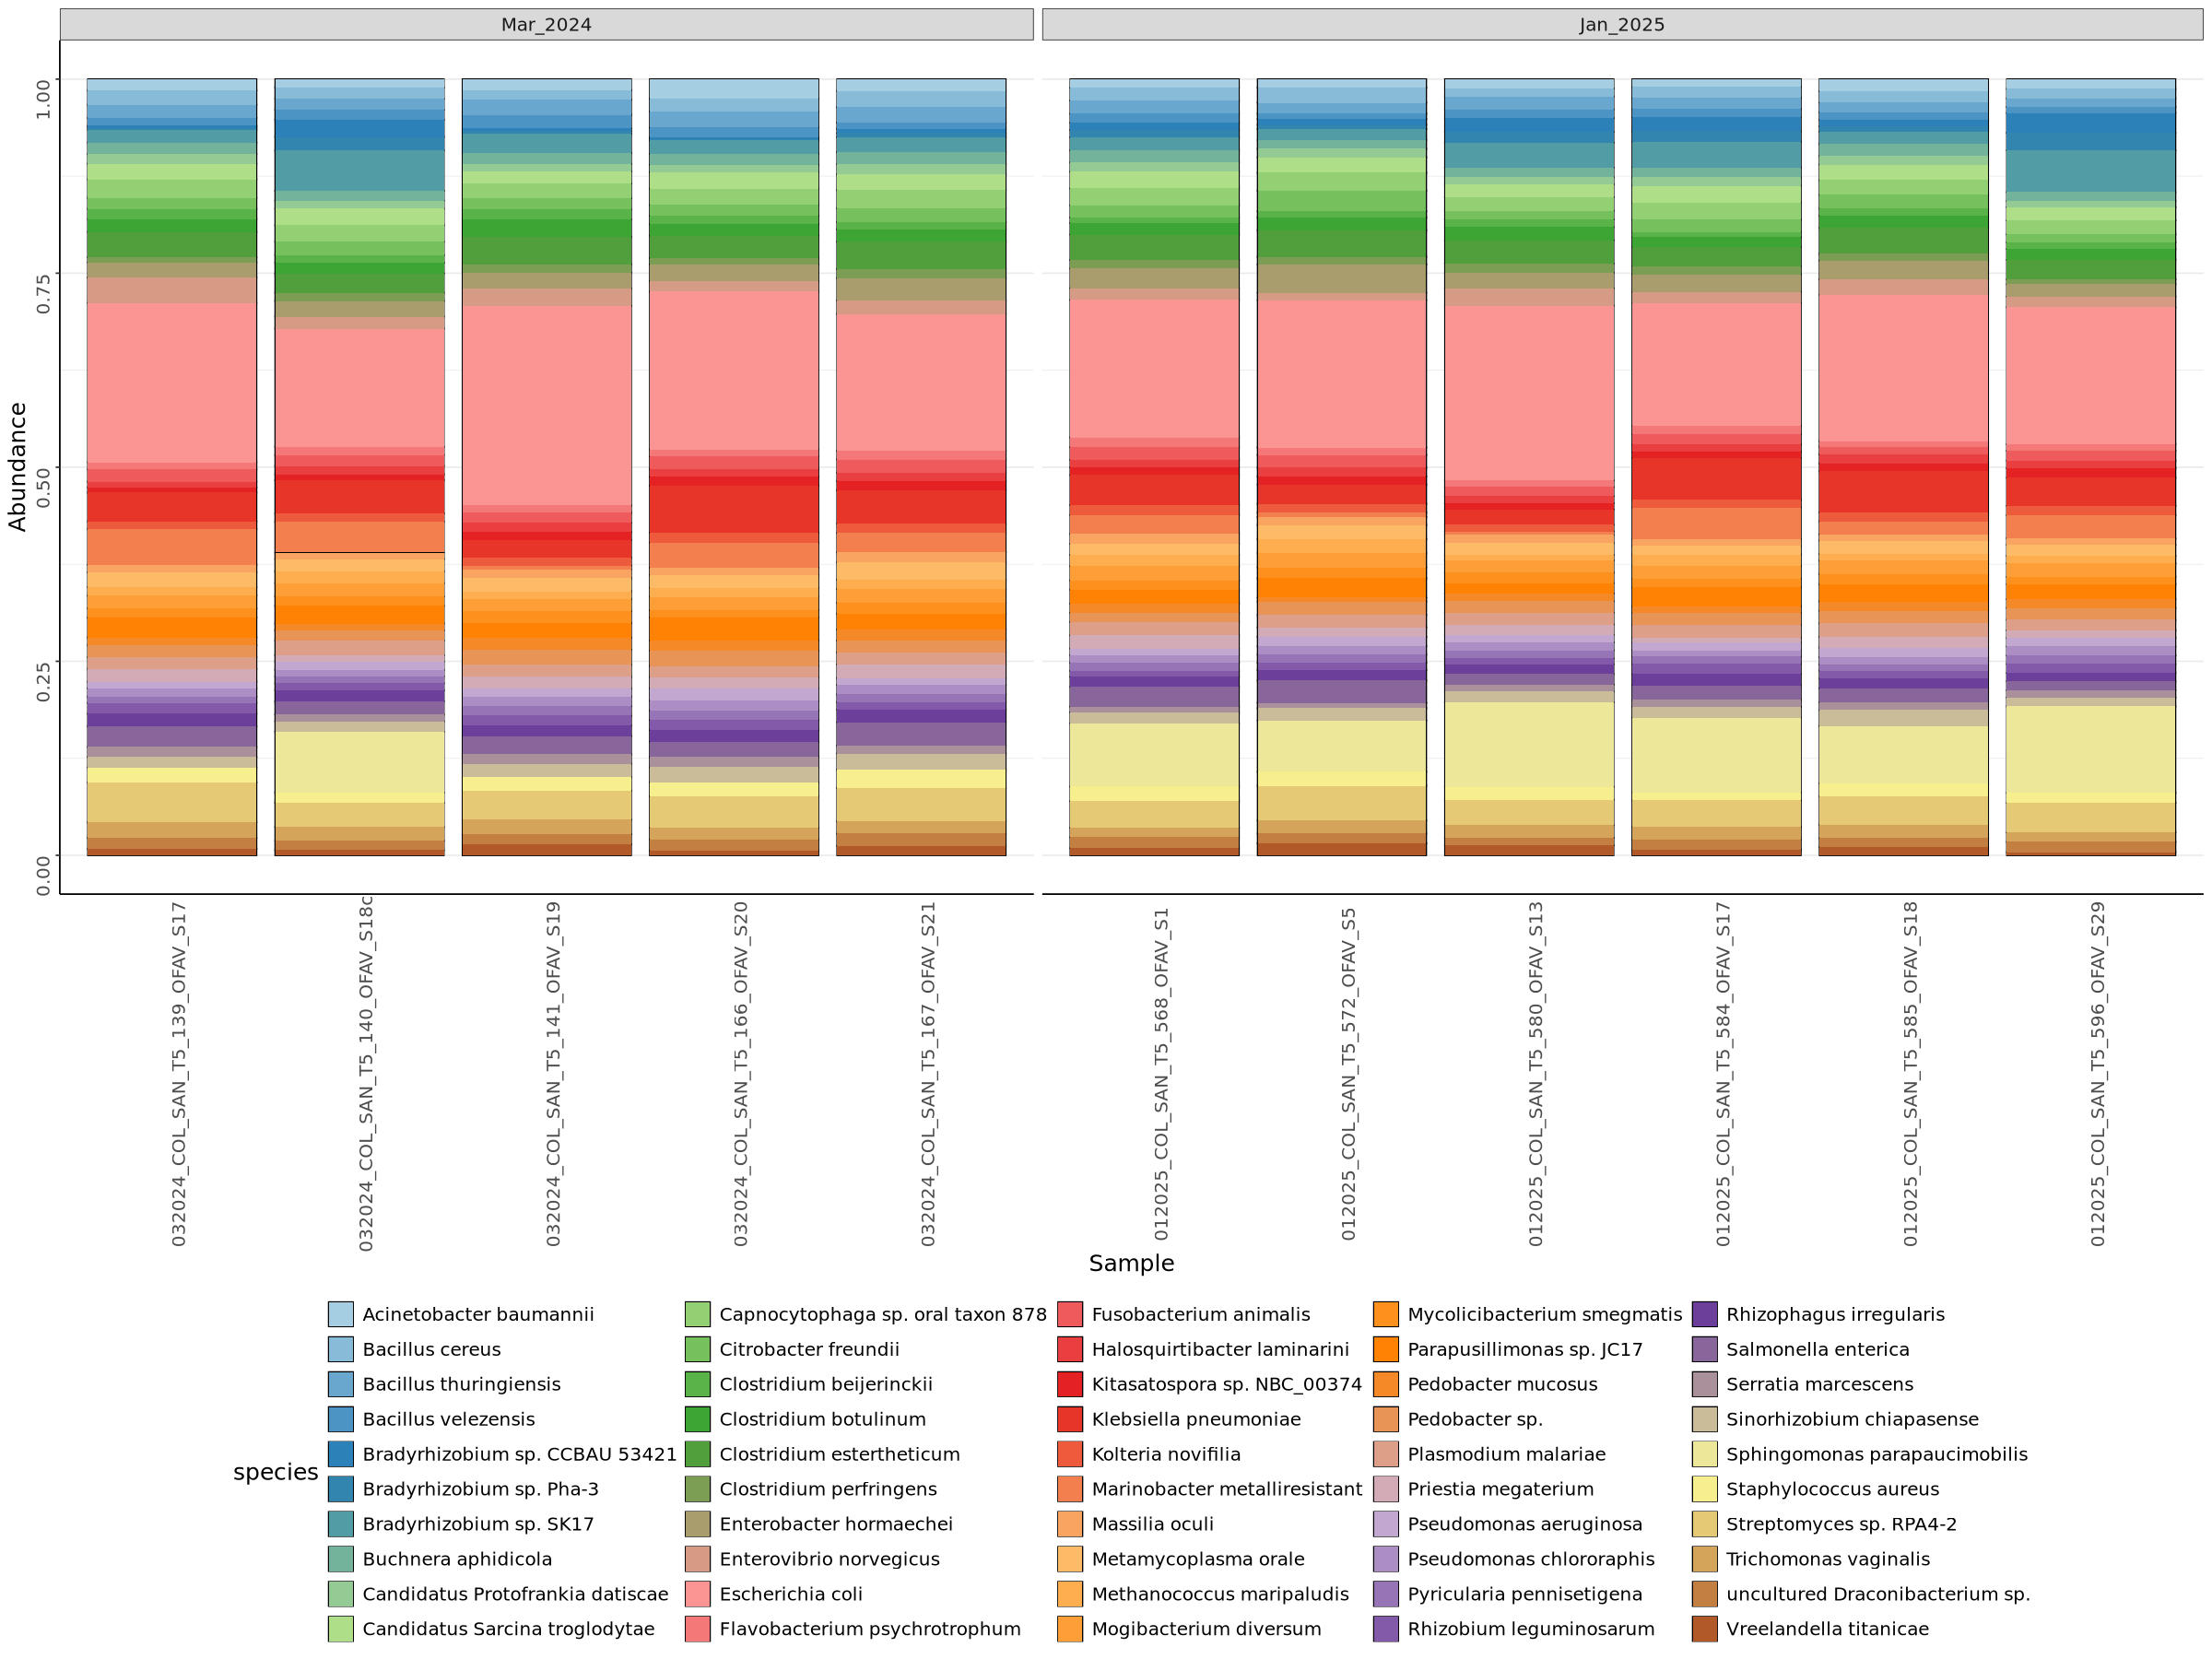

In [37]:
# bar plot of top 50 abundant taxa in OFAV samples
ofav_50_rel_bar<-plot_bar(COL_ofav_50_rel,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values = colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_50_rel_bar

In [41]:
ggsave(filename = "ofav_top_50_species_rel_bar.png", plot = ofav_50_rel_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

not a whole lot of variability between OFAV samples, is this weird? Going to look at MCAV samples

### MCAV

In [128]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken"

In [43]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_mcav = read.csv('mcav_otu_normtable_species.csv',header=TRUE)
head(otu_mcav)

,X,X032024_COL_SAN_T5_128_MCAV_S1,X032024_COL_SAN_T5_129_MCAV_S2,X032024_COL_SAN_T5_130_MCAV_S37,X032024_COL_SAN_T5_131_MCAV_S3,X032024_COL_SAN_T5_132_MCAV_S4,X032024_COL_SAN_T5_133_MCAV_S5,X032024_COL_SAN_T5_134_MCAV_S6,X032024_COL_SAN_T5_136_MCAV_S7,X032024_COL_SAN_T5_150_MCAV_S8,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_578_MCAV_S11,X012025_COL_SAN_T5_581_MCAV_S14,X012025_COL_SAN_T5_583_MCAV_S16,X012025_COL_SAN_T5_588_MCAV_S21,X012025_COL_SAN_T5_589_MCAV_S22,X012025_COL_SAN_T5_591_MCAV_S24,X012025_COL_SAN_T5_593_MCAV_S26,X012025_COL_SAN_T5_594_MCAV_S27,X012025_COL_SAN_T5_595_MCAV_S28
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,4660.8102,5826.327,8360.554,6601.744,7119.604,3650.8736,7897.859,8402.615,5793.08153,3445.536,4292.6904,4898.2781,4830.198,5562.750,3428.3976,4988.117,3614.050,4757.8904,5275.415
2,28213,0.0000,0.000,0.000,0.000,0.000,0.0000,0.000,0.000,79.45623,18077.076,19075.8015,23219.2405,25322.930,0.000,26644.7887,0.000,18196.584,21907.0826,0.000
3,573,3918.9849,8497.985,6260.694,6568.900,4810.364,5988.0895,7263.116,7997.788,13937.34515,4178.483,7207.4017,4051.8476,5283.434,5898.298,5656.0410,7904.698,7931.960,5058.1456,6494.500
4,2721244,366.0322,0.000,1114.740,0.000,0.000,0.0000,0.000,0.000,379.22292,0.000,482.6102,0.0000,0.000,0.000,298.8302,0.000,0.000,0.0000,0.000
5,238834,937.0425,1184.888,1134.184,2085.626,1151.311,673.2496,1050.967,1253.974,559.80526,1137.095,1206.5254,876.4813,1016.543,1022.372,1086.6553,1484.698,699.348,692.8967,1191.752
6,28901,3338.2138,2965.993,2560.015,3809.962,5849.191,3787.7129,1602.464,3900.156,7353.31296,2856.438,4953.1043,4417.4655,3787.756,4980.785,3689.1948,4835.539,3916.349,5433.4646,5023.944


In [44]:
# rename first col as otu
names(otu_mcav)[1] <- "otu"

#remove X's from headers
names(otu_mcav) <- sub("^X", "", names(otu_mcav))
otu_table_mcav=as.data.frame(otu_mcav)

# make the index the otus
row.names(otu_table_mcav) <- otu_table_mcav$otu
otu_table_mcav$otu <- NULL
head(otu_table_mcav)

,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_581_MCAV_S14,012025_COL_SAN_T5_583_MCAV_S16,012025_COL_SAN_T5_588_MCAV_S21,012025_COL_SAN_T5_589_MCAV_S22,012025_COL_SAN_T5_591_MCAV_S24,012025_COL_SAN_T5_593_MCAV_S26,012025_COL_SAN_T5_594_MCAV_S27,012025_COL_SAN_T5_595_MCAV_S28
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,4660.8102,5826.327,8360.554,6601.744,7119.604,3650.8736,7897.859,8402.615,5793.08153,3445.536,4292.6904,4898.2781,4830.198,5562.750,3428.3976,4988.117,3614.050,4757.8904,5275.415
28213,0.0000,0.000,0.000,0.000,0.000,0.0000,0.000,0.000,79.45623,18077.076,19075.8015,23219.2405,25322.930,0.000,26644.7887,0.000,18196.584,21907.0826,0.000
573,3918.9849,8497.985,6260.694,6568.900,4810.364,5988.0895,7263.116,7997.788,13937.34515,4178.483,7207.4017,4051.8476,5283.434,5898.298,5656.0410,7904.698,7931.960,5058.1456,6494.500
2721244,366.0322,0.000,1114.740,0.000,0.000,0.0000,0.000,0.000,379.22292,0.000,482.6102,0.0000,0.000,0.000,298.8302,0.000,0.000,0.0000,0.000
238834,937.0425,1184.888,1134.184,2085.626,1151.311,673.2496,1050.967,1253.974,559.80526,1137.095,1206.5254,876.4813,1016.543,1022.372,1086.6553,1484.698,699.348,692.8967,1191.752
28901,3338.2138,2965.993,2560.015,3809.962,5849.191,3787.7129,1602.464,3900.156,7353.31296,2856.438,4953.1043,4417.4655,3787.756,4980.785,3689.1948,4835.539,3916.349,5433.4646,5023.944


In [45]:
# sort by most abundant OTUs
otus_sorted_mcav <- otu_table_mcav[order(rowSums(otu_table_mcav), decreasing = TRUE), ]
head(otus_sorted_mcav)

,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_581_MCAV_S14,012025_COL_SAN_T5_583_MCAV_S16,012025_COL_SAN_T5_588_MCAV_S21,012025_COL_SAN_T5_589_MCAV_S22,012025_COL_SAN_T5_591_MCAV_S24,012025_COL_SAN_T5_593_MCAV_S26,012025_COL_SAN_T5_594_MCAV_S27,012025_COL_SAN_T5_595_MCAV_S28
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,204900.000,132502.000,154296.000,60893.000,151132.000,182696.000,96102.000,101278.000,276882.00000,145986.000,157477.000,199662.000,154445.000,190733.0000,184051.000,170405.0000,221635.000,173186.000,182924.0000
28213,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,79.45623,18077.076,19075.802,23219.241,25322.930,0.0000,26644.789,0.0000,18196.584,21907.083,0.0000
573,3918.985,8497.985,6260.694,6568.900,4810.364,5988.090,7263.116,7997.788,13937.34515,4178.483,7207.402,4051.848,5283.434,5898.2976,5656.041,7904.6976,7931.960,5058.146,6494.5004
2057741,7393.851,13750.736,24141.909,6552.477,2600.376,2589.000,5421.323,2567.191,4102.83081,3897.634,5842.123,4587.753,5678.397,477.1067,6259.135,217.1298,7119.814,5629.785,164.0025
1280,2493.899,2437.699,4938.560,7537.812,4955.933,5484.521,5410.918,5746.559,2567.88090,4349.732,10096.713,5334.014,6902.133,2479.9065,6036.370,7986.8548,11081.282,7541.025,4132.8639
562,4660.810,5826.327,8360.554,6601.744,7119.604,3650.874,7897.859,8402.615,5793.08153,3445.536,4292.690,4898.278,4830.198,5562.7500,3428.398,4988.1165,3614.050,4757.890,5275.4149


In [46]:
#remove total reads row
otus_sorted_mcav <- otus_sorted_mcav[-1, ]
head(otus_sorted_mcav)
dim (otus_sorted_mcav)

,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_581_MCAV_S14,012025_COL_SAN_T5_583_MCAV_S16,012025_COL_SAN_T5_588_MCAV_S21,012025_COL_SAN_T5_589_MCAV_S22,012025_COL_SAN_T5_591_MCAV_S24,012025_COL_SAN_T5_593_MCAV_S26,012025_COL_SAN_T5_594_MCAV_S27,012025_COL_SAN_T5_595_MCAV_S28
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
28213,0.0000,0.000,0.000,0.000,0.000,0.0000,0.0000,0.0000,79.45623,18077.0759,19075.802,23219.2405,25322.9305,0.0000,26644.7887,0.0000,18196.5845,21907.0826,0.0000
573,3918.9849,8497.985,6260.694,6568.900,4810.364,5988.0895,7263.1163,7997.7883,13937.34515,4178.4829,7207.402,4051.8476,5283.4342,5898.2976,5656.0410,7904.6976,7931.9602,5058.1456,6494.5004
2057741,7393.8507,13750.736,24141.909,6552.477,2600.376,2589.0003,5421.3232,2567.1913,4102.83081,3897.6340,5842.123,4587.7533,5678.3968,477.1067,6259.1347,217.1298,7119.8141,5629.7853,164.0025
1280,2493.8995,2437.699,4938.560,7537.812,4955.933,5484.5207,5410.9176,5746.5590,2567.88090,4349.7322,10096.713,5334.0145,6902.1334,2479.9065,6036.3704,7986.8548,11081.2823,7541.0253,4132.8639
562,4660.8102,5826.327,8360.554,6601.744,7119.604,3650.8736,7897.8585,8402.6146,5793.08153,3445.5359,4292.690,4898.2781,4830.1985,5562.7500,3428.3976,4988.1165,3614.0501,4757.8904,5275.4149
28108,941.9229,52655.809,13752.787,4828.141,2415.107,700.6174,770.0152,641.7978,7494.16719,917.8962,615.963,380.6433,789.9252,361.7623,630.2601,639.6526,563.9903,612.0587,475.6074


[1] 13367    19

In [47]:
# Convert to matrix
otus_mcav=as.matrix(otus_sorted_mcav)
head(otus_mcav)

,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_581_MCAV_S14,012025_COL_SAN_T5_583_MCAV_S16,012025_COL_SAN_T5_588_MCAV_S21,012025_COL_SAN_T5_589_MCAV_S22,012025_COL_SAN_T5_591_MCAV_S24,012025_COL_SAN_T5_593_MCAV_S26,012025_COL_SAN_T5_594_MCAV_S27,012025_COL_SAN_T5_595_MCAV_S28
28213,0.0000,0.000,0.000,0.000,0.000,0.0000,0.0000,0.0000,79.45623,18077.0759,19075.802,23219.2405,25322.9305,0.0000,26644.7887,0.0000,18196.5845,21907.0826,0.0000
573,3918.9849,8497.985,6260.694,6568.900,4810.364,5988.0895,7263.1163,7997.7883,13937.34515,4178.4829,7207.402,4051.8476,5283.4342,5898.2976,5656.0410,7904.6976,7931.9602,5058.1456,6494.5004
2057741,7393.8507,13750.736,24141.909,6552.477,2600.376,2589.0003,5421.3232,2567.1913,4102.83081,3897.6340,5842.123,4587.7533,5678.3968,477.1067,6259.1347,217.1298,7119.8141,5629.7853,164.0025
1280,2493.8995,2437.699,4938.560,7537.812,4955.933,5484.5207,5410.9176,5746.5590,2567.88090,4349.7322,10096.713,5334.0145,6902.1334,2479.9065,6036.3704,7986.8548,11081.2823,7541.0253,4132.8639
562,4660.8102,5826.327,8360.554,6601.744,7119.604,3650.8736,7897.8585,8402.6146,5793.08153,3445.5359,4292.690,4898.2781,4830.1985,5562.7500,3428.3976,4988.1165,3614.0501,4757.8904,5275.4149
28108,941.9229,52655.809,13752.787,4828.141,2415.107,700.6174,770.0152,641.7978,7494.16719,917.8962,615.963,380.6433,789.9252,361.7623,630.2601,639.6526,563.9903,612.0587,475.6074


In [48]:
#filter metadata for mcavs only
metadata_mcav <- metadata[metadata$Species=="MCAV",]
head(metadata_mcav)
dim(metadata_mcav)

,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_128_MCAV_S1,ELARBOL,3/7/24,Mar_2024,8,MCAV,Healthy,Healthy,,,
032024_COL_SAN_T5_129_MCAV_S2,ELARBOL,3/7/24,Mar_2024,14,MCAV,Healthy,Diseased,,,
032024_COL_SAN_T5_130_MCAV_S37,ELARBOL,3/7/24,Mar_2024,7,MCAV,Healthy,Healthy,,,
032024_COL_SAN_T5_131_MCAV_S3,ELARBOL,3/7/24,Mar_2024,6,MCAV,Healthy,Healthy,,,
032024_COL_SAN_T5_132_MCAV_S4,ELARBOL,3/7/24,Mar_2024,5,MCAV,Healthy,Healthy,,,
032024_COL_SAN_T5_133_MCAV_S5,ELARBOL,3/7/24,Mar_2024,13,MCAV,Healthy,Healthy,,,


[1] 19 10

In [49]:
# classify phyloseq objects 
OTU_M=otu_table((otus_mcav), taxa_are_rows = TRUE)
TAX_M=tax_table(taxonomy)
SAMP_M=sample_data(metadata_mcav)

In [50]:
# Create phyloseq object
COL_mcav = phyloseq(OTU_M, SAMP_M, TAX_M)
COL_mcav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13367 taxa and 19 samples ]
sample_data() Sample Data:       [ 19 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 13367 taxa by 1 taxonomic ranks ]

In [51]:
COL_mcav_10 = prune_taxa(names(sort(taxa_sums(COL_mcav),TRUE)[1:10]), COL_mcav)

In [52]:
#order of facets
sample_data(COL_mcav_10)$Year_m <- factor(sample_data(COL_mcav_10)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

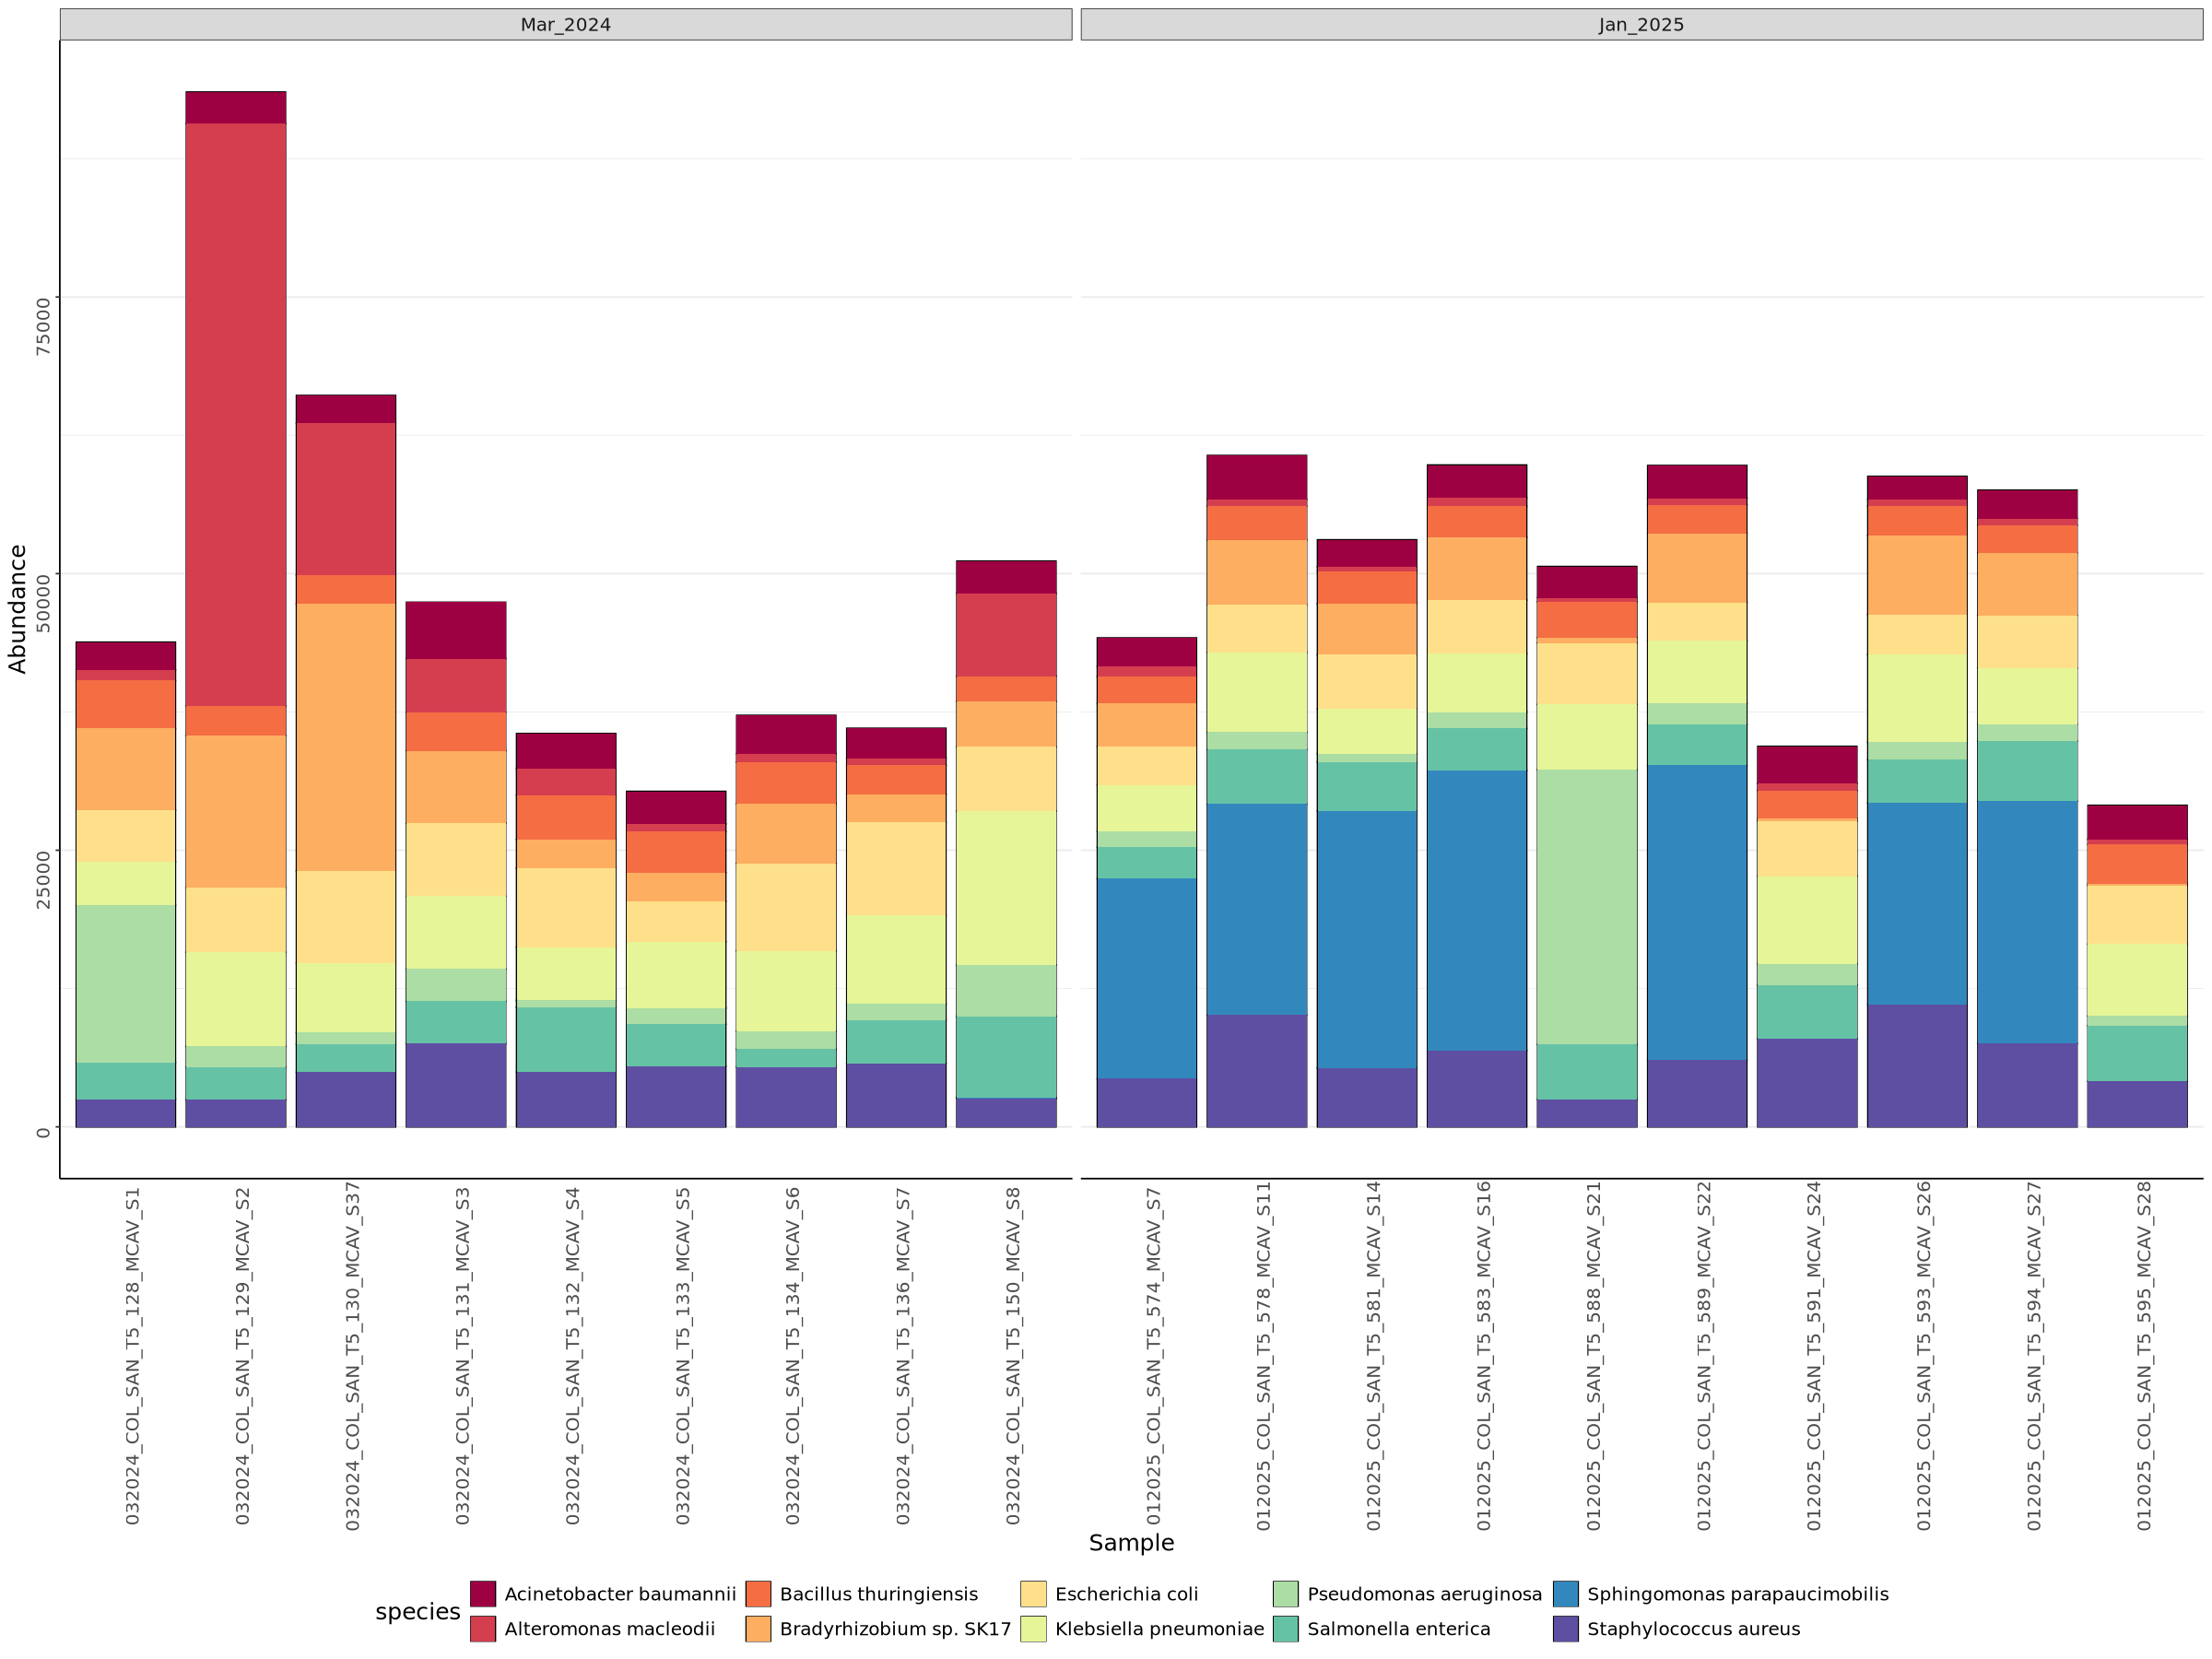

In [53]:
# bar plot of top 10 abundant taxa in MCAV samples
mcav_10_bar<-plot_bar(COL_mcav_10,fill='species')+
facet_grid(~Year_m, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
mcav_10_bar

In [54]:
ggsave(filename = "mcav_top_10_species_bar.png", plot = mcav_10_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

In [55]:
COL_mcav_10_rel <- transform_sample_counts(COL_mcav_10, function(x) x / sum(x))

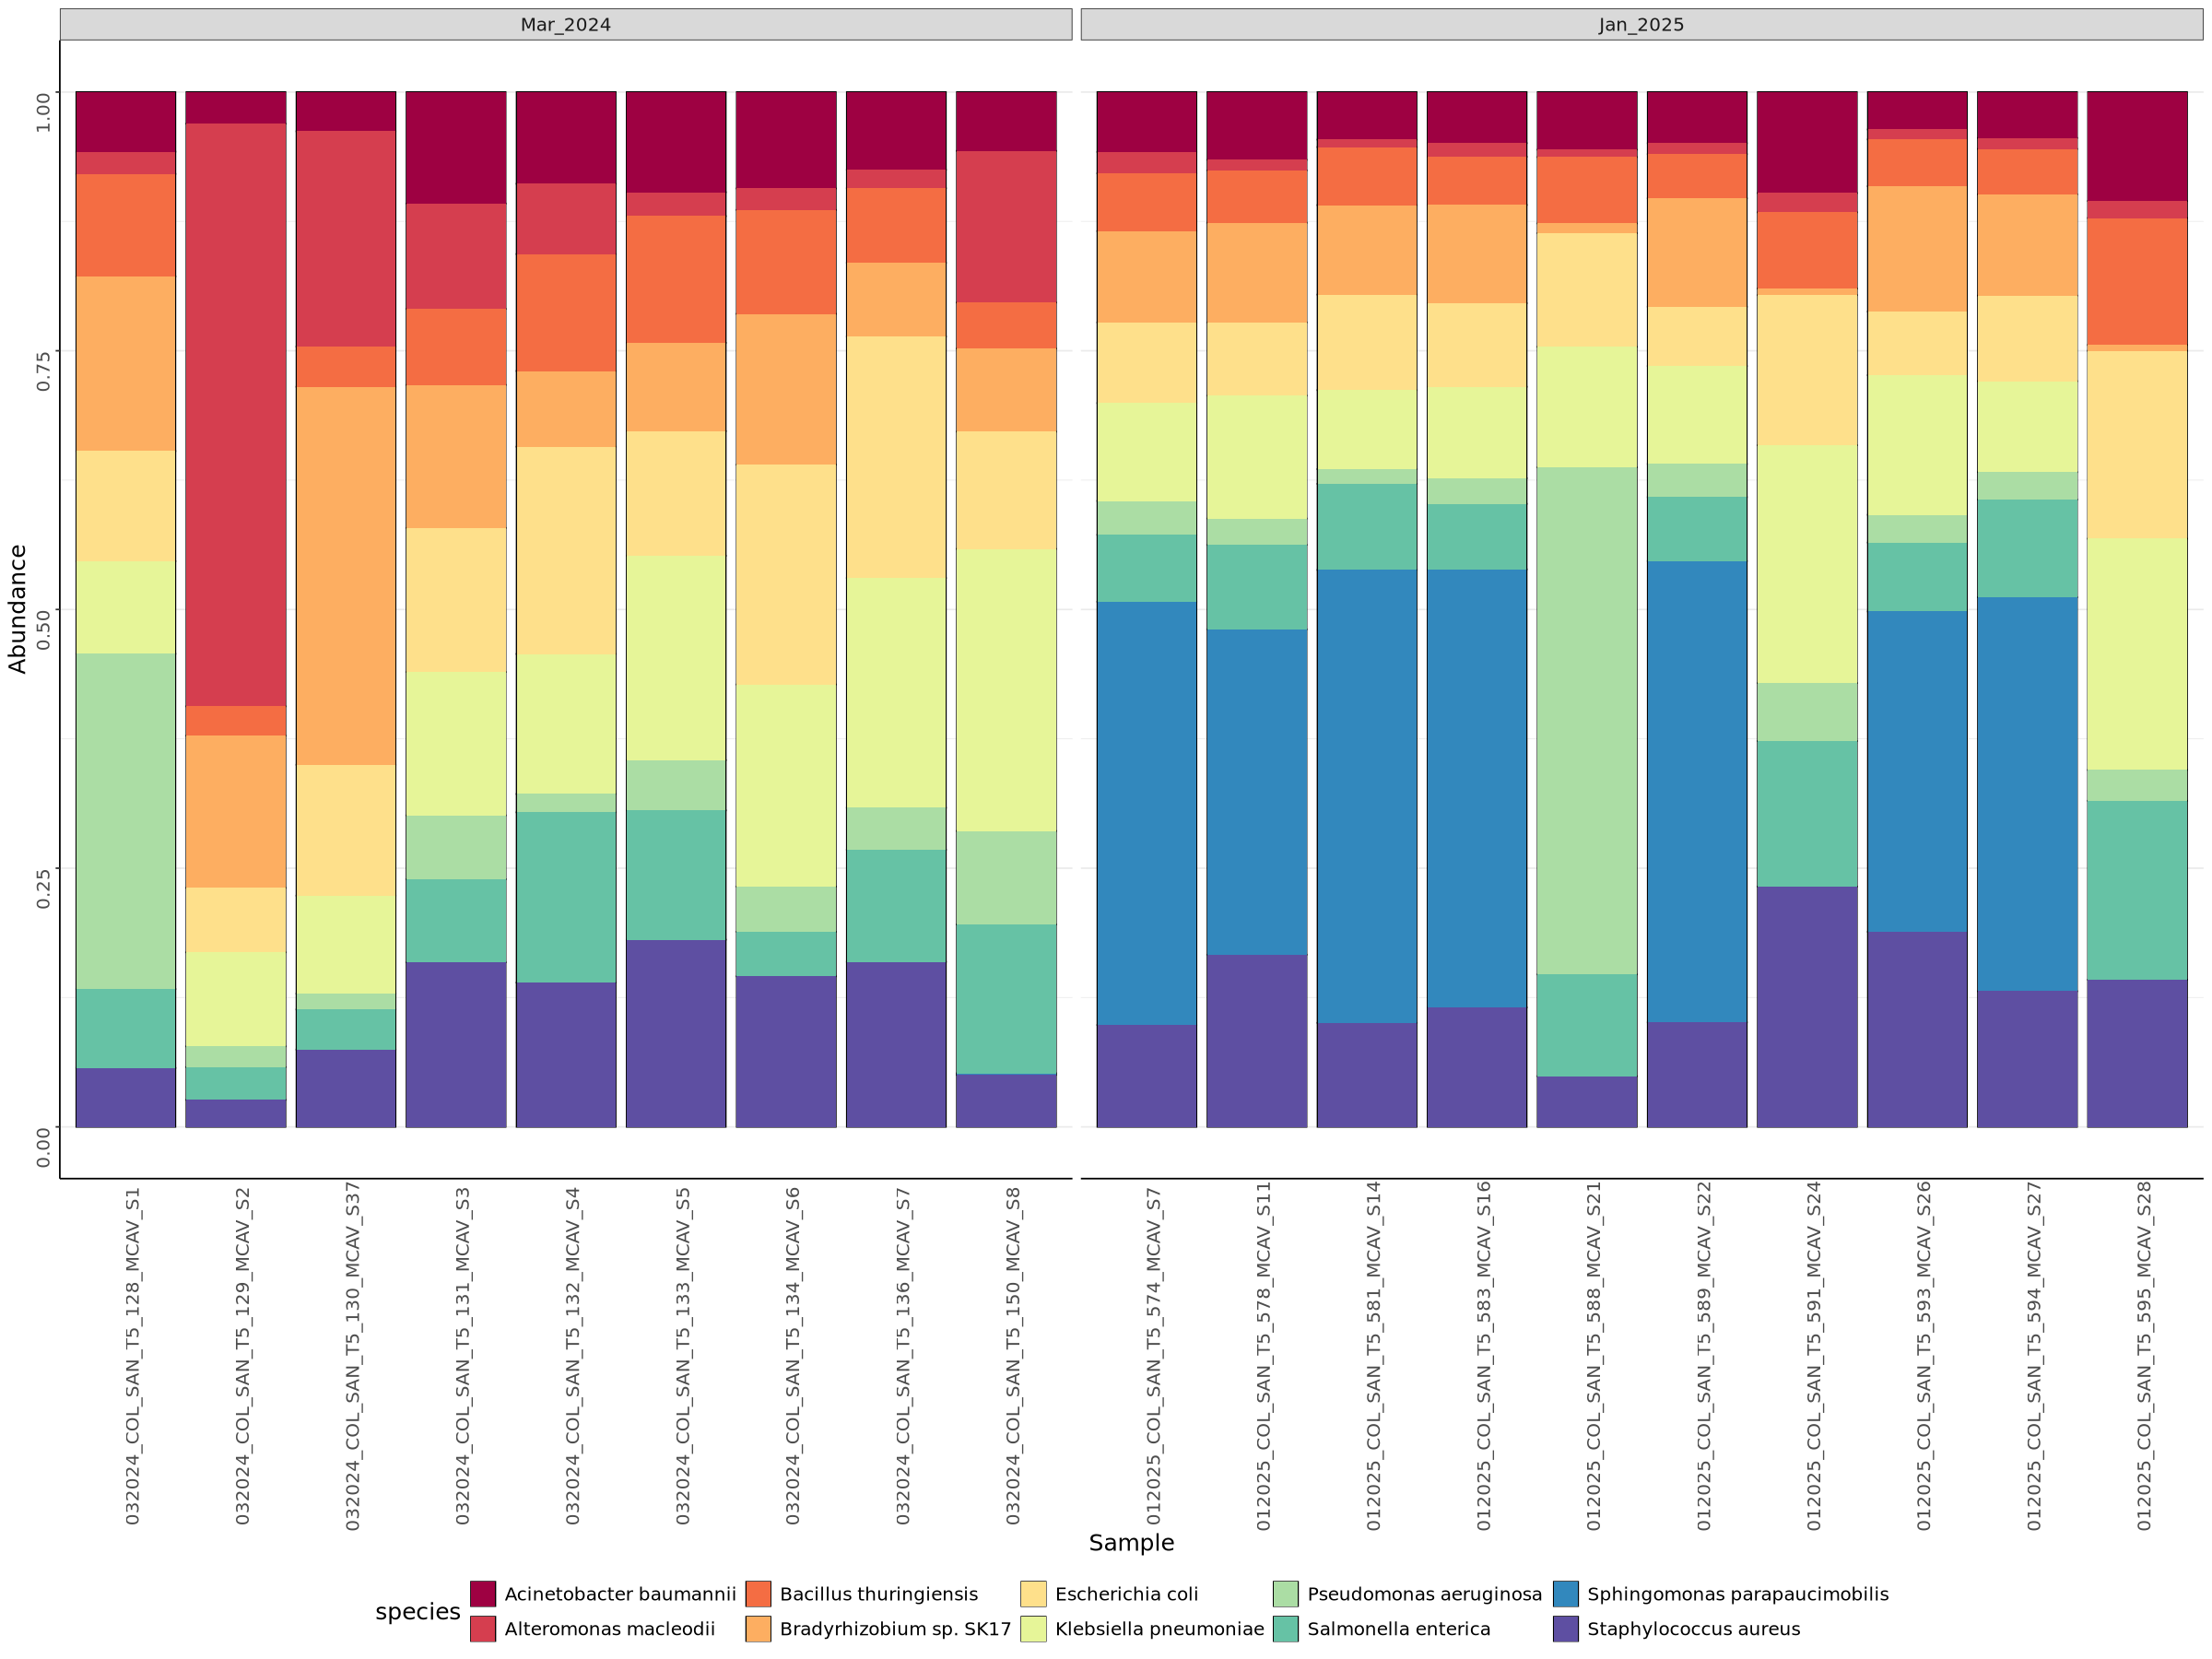

In [56]:
# bar plot of top 10 relative abundances in MCAV samples
mcav_10_rel_bar<-plot_bar(COL_mcav_10_rel,fill='species')+
facet_grid(~Year_m, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
mcav_10_rel_bar

In [57]:
ggsave(filename = "mcav_top_10_species_rel_bar.png", plot = mcav_10_rel_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

In [59]:
#now do top 50
COL_mcav_50 = prune_taxa(names(sort(taxa_sums(COL_mcav),TRUE)[1:50]), COL_mcav)

In [60]:
sample_data(COL_mcav_50)$Year_o <- factor(sample_data(COL_mcav_50)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

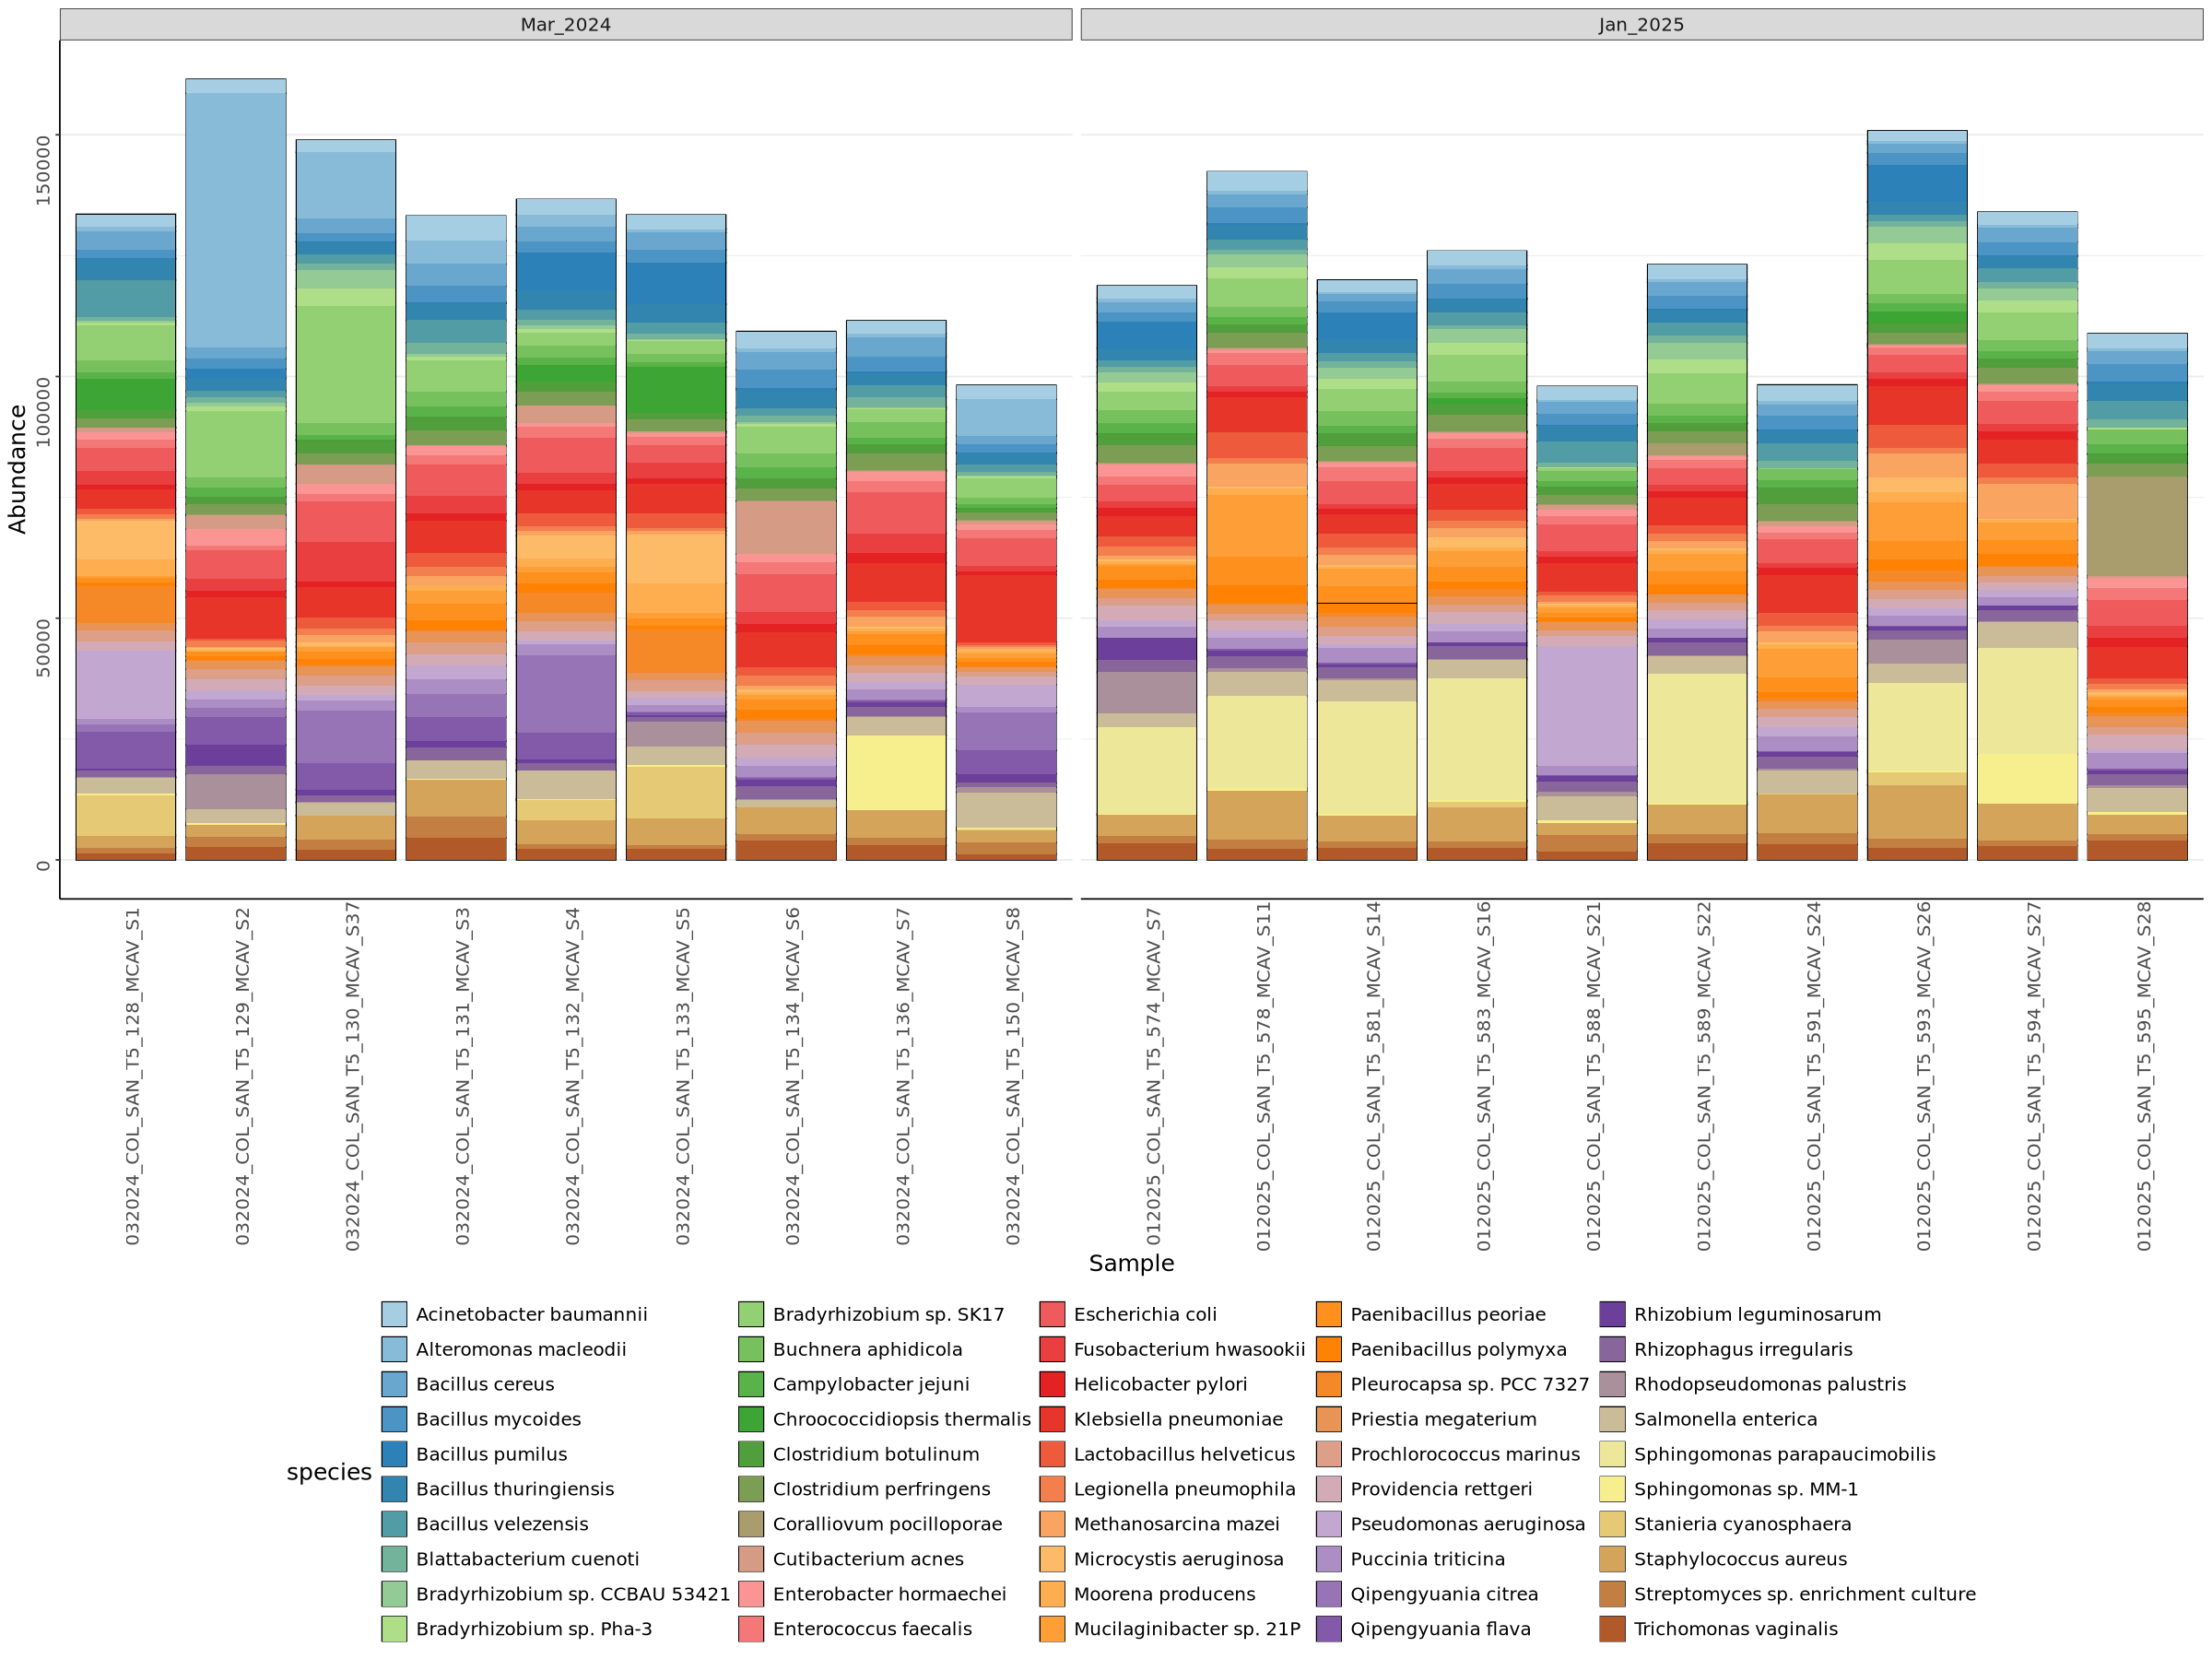

In [61]:
# bar plot of top 50 abundant taxa in MCAV samples
mcav_50_bar<-plot_bar(COL_mcav_50,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values = colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
mcav_50_bar

In [62]:
ggsave(filename = "mcav_top_50_species_bar.png", plot = mcav_50_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

In [63]:
COL_mcav_50_rel <- transform_sample_counts(COL_mcav_50, function(x) x / sum(x))

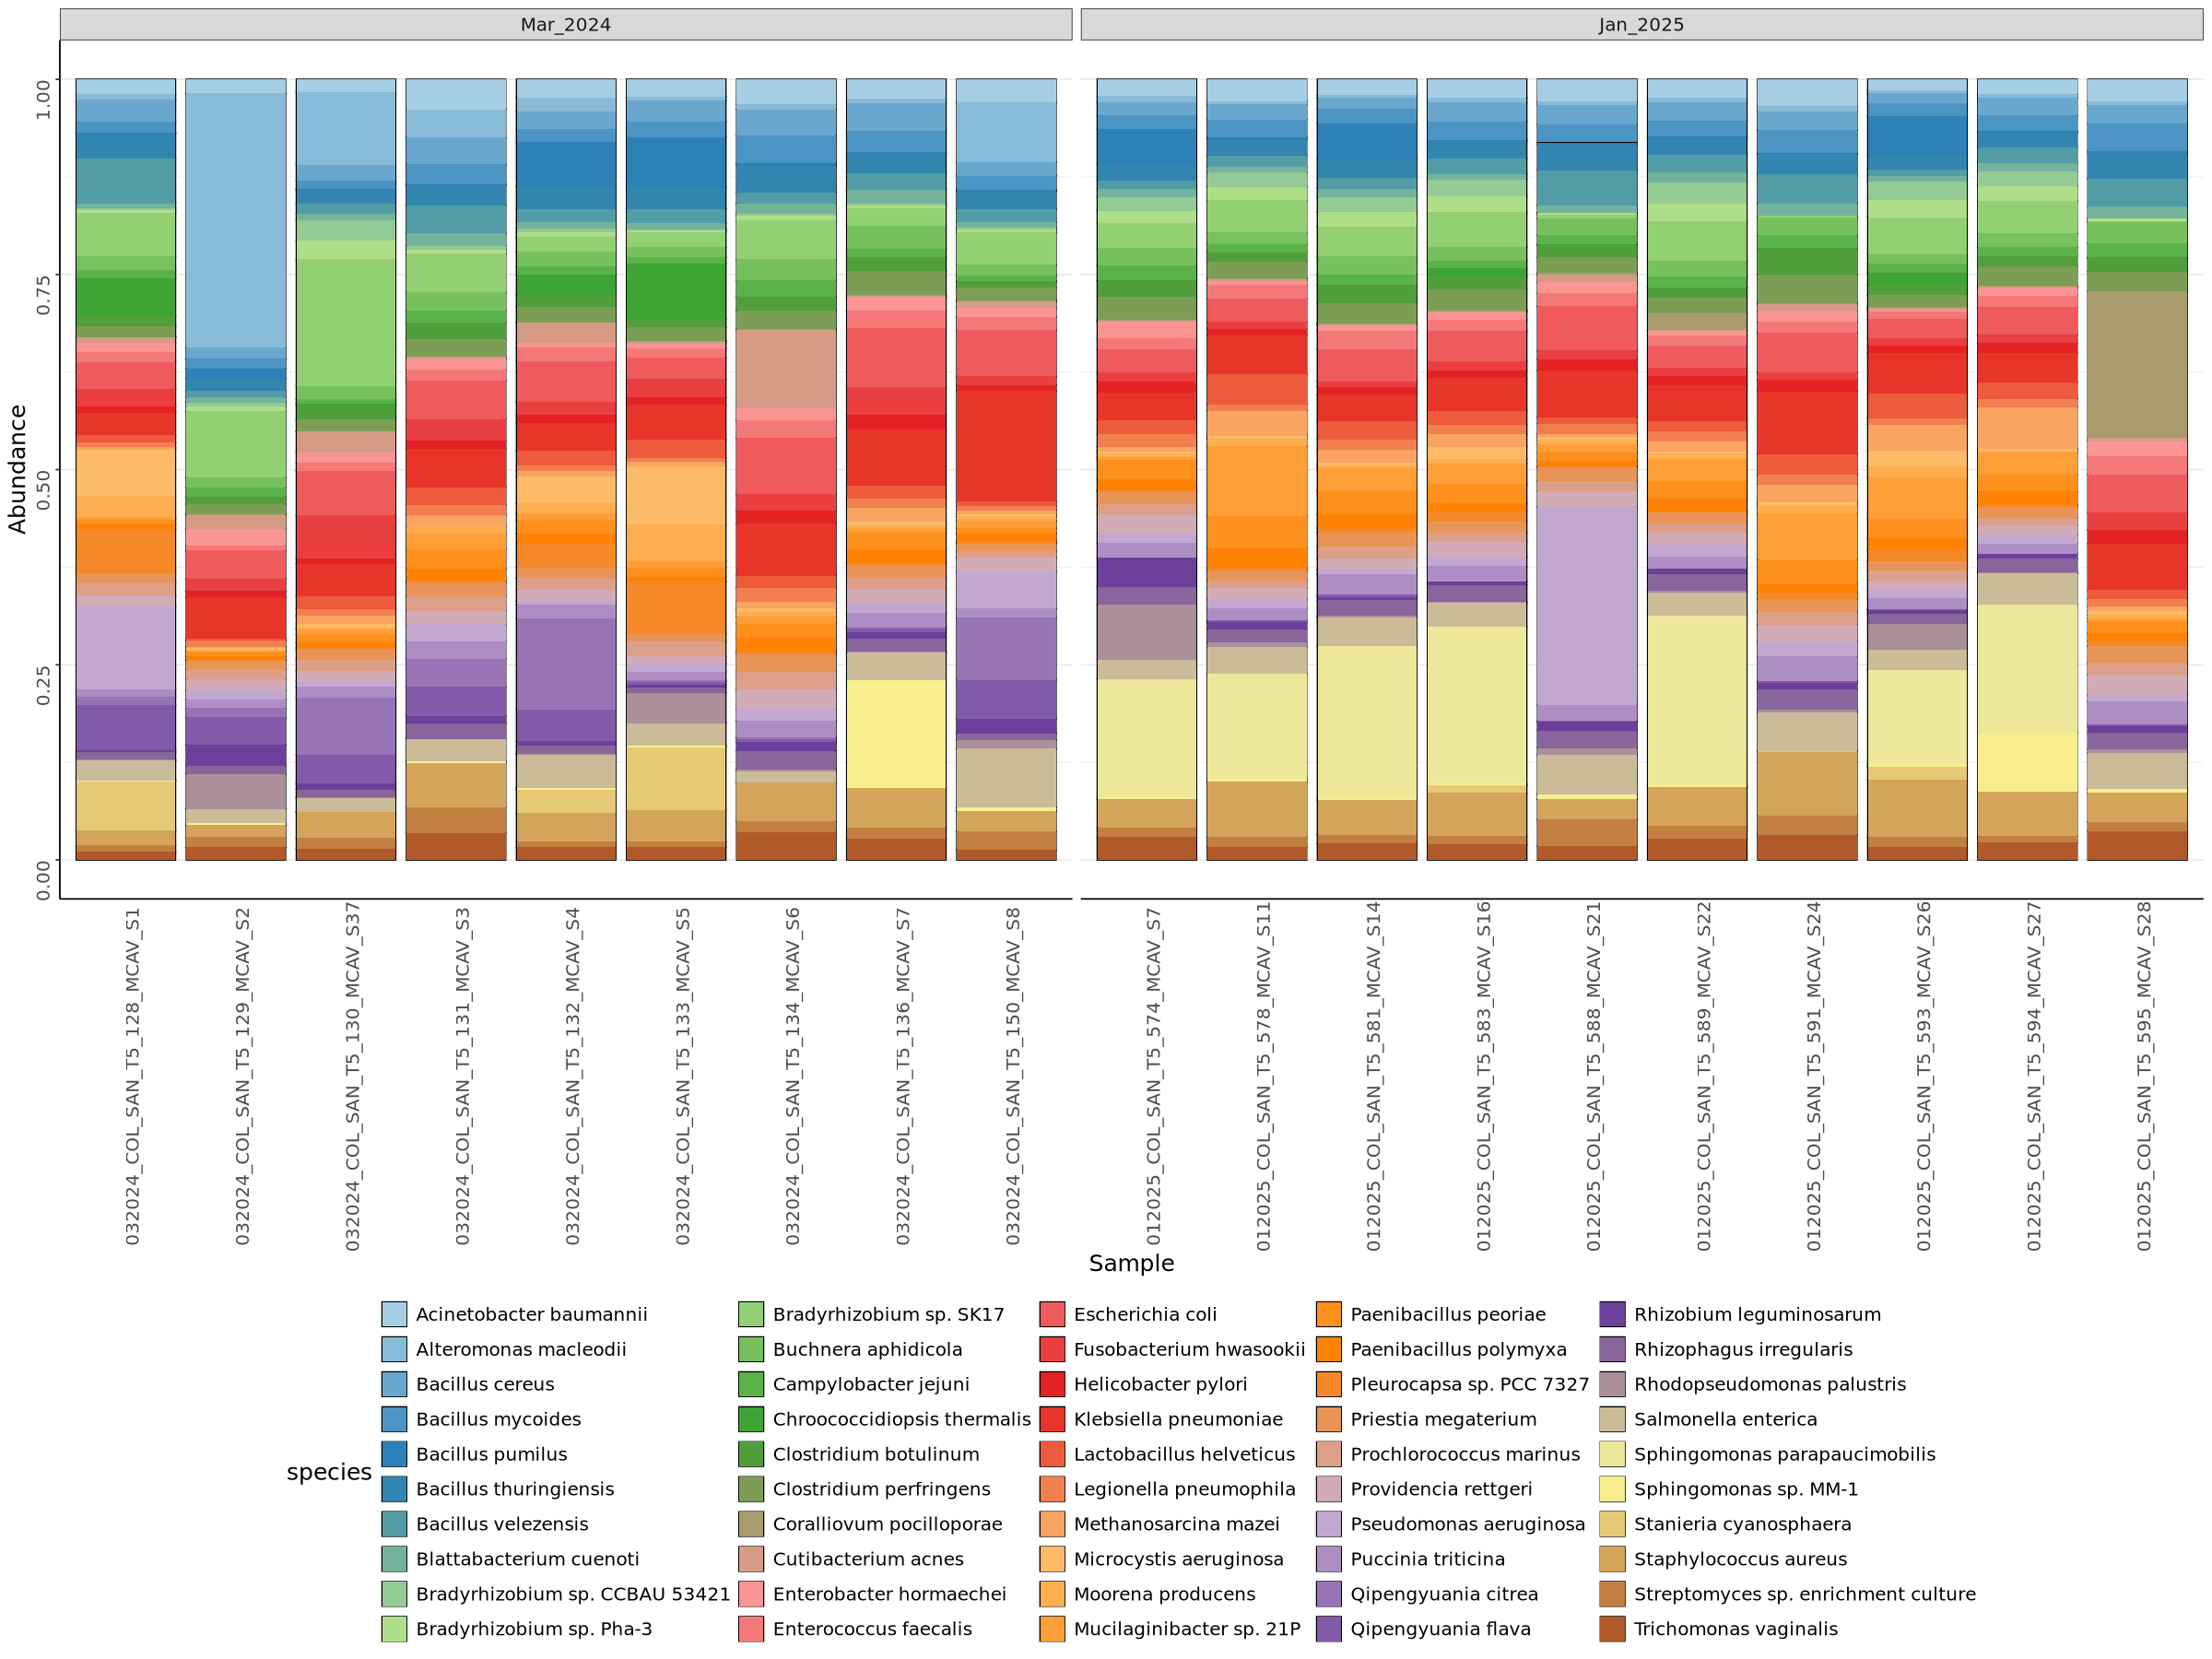

In [64]:
# bar plot of top 50 abundant taxa in OFAV samples
mcav_50_rel_bar<-plot_bar(COL_mcav_50_rel,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values = colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
mcav_50_rel_bar

In [65]:
ggsave(filename = "mcav_top_50_species_rel_bar.png", plot = mcav_50_rel_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

### DLAB

In [80]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_dlab = read.csv('dlab_otu_normtable_species.csv',header=TRUE)
head(otu_dlab)

,X,X032024_COL_SAN_T5_143_DLAB_S40,X032024_COL_SAN_T5_146_DLAB_S12,X032024_COL_SAN_T5_148_DLAB_S13,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_579_DLAB_S12,X012025_COL_SAN_T5_586_DLAB_S19,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,7353.4309,7019.0504,8008.5895,6314.141,6388.731,6552.0784,14466.5859,5914.3961,25162.0014,63189.7472,6465.2993,17431.8933,8454.3909,712158.8
2,28213,0.0000,0.0000,0.0000,0.000,0.000,0.0000,102.6370,213.2229,536.7477,618.3133,4841.8426,218.6513,235.6799,280683.9
3,573,3610.8400,2832.8215,4018.3168,2870.830,2313.967,1991.2673,2518.7967,4629.9822,2191.2854,3232.0923,5776.7566,2828.2066,8629.8973,280485.3
4,2721244,810.7740,448.0245,1506.3680,1010.263,1164.775,777.9195,210.5107,1137.1886,177.1788,883.7509,403.2708,0.0000,1263.6456,90790.5
5,238834,676.1276,1171.3974,953.4989,1245.991,1172.566,1061.8945,821.0963,715.8196,609.7037,493.4015,226.9209,716.1621,852.4593,102676.0
6,28901,5808.6168,2814.1538,3385.3217,3725.343,2945.049,3560.8748,11139.2607,1761.6270,1818.6887,5502.3640,1980.0465,14389.7887,1995.7578,218394.0


In [81]:
# rename first col as otu
names(otu_dlab)[1] <- "otu"

#remove X's from headers
names(otu_dlab) <- sub("^X", "", names(otu_dlab))
otu_table_dlab=as.data.frame(otu_dlab)

# make the index the otus
row.names(otu_table_dlab) <- otu_table_dlab$otu
otu_table_dlab$otu <- NULL
head(otu_table_dlab)

,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_579_DLAB_S12,012025_COL_SAN_T5_586_DLAB_S19,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,7353.4309,7019.0504,8008.5895,6314.141,6388.731,6552.0784,14466.5859,5914.3961,25162.0014,63189.7472,6465.2993,17431.8933,8454.3909,712158.8
28213,0.0000,0.0000,0.0000,0.000,0.000,0.0000,102.6370,213.2229,536.7477,618.3133,4841.8426,218.6513,235.6799,280683.9
573,3610.8400,2832.8215,4018.3168,2870.830,2313.967,1991.2673,2518.7967,4629.9822,2191.2854,3232.0923,5776.7566,2828.2066,8629.8973,280485.3
2721244,810.7740,448.0245,1506.3680,1010.263,1164.775,777.9195,210.5107,1137.1886,177.1788,883.7509,403.2708,0.0000,1263.6456,90790.5
238834,676.1276,1171.3974,953.4989,1245.991,1172.566,1061.8945,821.0963,715.8196,609.7037,493.4015,226.9209,716.1621,852.4593,102676.0
28901,5808.6168,2814.1538,3385.3217,3725.343,2945.049,3560.8748,11139.2607,1761.6270,1818.6887,5502.3640,1980.0465,14389.7887,1995.7578,218394.0


In [82]:
# sort by most abundant OTUs
otus_sorted_dlab <- otu_table_dlab[order(rowSums(otu_table_dlab), decreasing = TRUE), ]
head(otus_sorted_dlab)

,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_579_DLAB_S12,012025_COL_SAN_T5_586_DLAB_S19,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,690698.00000,214274.00000,249607.0000,237562.00000,256702.0000,581037.00000,954821.00000,196977.0000,383793.00000,320226.0000,771194.00000,631142.0000,199423.00000,18715839.0
562,7353.43088,7019.05037,8008.5895,6314.14115,6388.7309,6552.07844,14466.58588,5914.3961,25162.00139,63189.7472,6465.29926,17431.8933,8454.39092,712158.8
2057741,15352.58536,6986.38192,9847.4802,4095.77289,2746.3752,31741.52421,16684.80270,436.5992,1292.36333,412.2089,1680.51100,359.6655,140.40507,417832.6
2653203,55.01681,60.66998,0.0000,58.93198,0.0000,0.00000,162.33409,29049.0768,65691.66191,73057.7779,3633.32702,9557.2787,3710.70539,263658.8
1173583,88.31646,112.00612,136.2141,101.02626,151.9271,58.51607,65.98095,0.0000,28.66128,0.0000,22.04374,53.8706,50.14467,420910.3
1747,2193.43331,896.04898,304.4786,328.33534,229.8385,6008.22323,3863.55139,8813.2117,26092.19032,70103.6143,129.66906,7598.9239,6288.14129,218157.0


In [83]:
#remove total reads row
otus_sorted_dlab <- otus_sorted_dlab[-1, ]
head(otus_sorted_dlab)
dim (otus_sorted_dlab)

,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_579_DLAB_S12,012025_COL_SAN_T5_586_DLAB_S19,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,7353.43088,7019.05037,8008.5895,6314.14115,6388.7309,6552.07844,14466.58588,5914.3961,25162.00139,63189.7472,6465.29926,17431.8933,8454.39092,712158.8
2057741,15352.58536,6986.38192,9847.4802,4095.77289,2746.3752,31741.52421,16684.80270,436.5992,1292.36333,412.2089,1680.51100,359.6655,140.40507,417832.6
2653203,55.01681,60.66998,0.0000,58.93198,0.0000,0.00000,162.33409,29049.0768,65691.66191,73057.7779,3633.32702,9557.2787,3710.70539,263658.8
1173583,88.31646,112.00612,136.2141,101.02626,151.9271,58.51607,65.98095,0.0000,28.66128,0.0000,22.04374,53.8706,50.14467,420910.3
1747,2193.43331,896.04898,304.4786,328.33534,229.8385,6008.22323,3863.55139,8813.2117,26092.19032,70103.6143,129.66906,7598.9239,6288.14129,218157.0
573,3610.84005,2832.82153,4018.3168,2870.82951,2313.9672,1991.26734,2518.79672,4629.9822,2191.28541,3232.0923,5776.75656,2828.2066,8629.89725,280485.3


[1] 13367    14

In [84]:
#remove Sum column
otus_sorted_dlab$Sum <- NULL
head(otus_sorted_dlab)

,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_579_DLAB_S12,012025_COL_SAN_T5_586_DLAB_S19
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,7353.43088,7019.05037,8008.5895,6314.14115,6388.7309,6552.07844,14466.58588,5914.3961,25162.00139,63189.7472,6465.29926,17431.8933,8454.39092
2057741,15352.58536,6986.38192,9847.4802,4095.77289,2746.3752,31741.52421,16684.80270,436.5992,1292.36333,412.2089,1680.51100,359.6655,140.40507
2653203,55.01681,60.66998,0.0000,58.93198,0.0000,0.00000,162.33409,29049.0768,65691.66191,73057.7779,3633.32702,9557.2787,3710.70539
1173583,88.31646,112.00612,136.2141,101.02626,151.9271,58.51607,65.98095,0.0000,28.66128,0.0000,22.04374,53.8706,50.14467
1747,2193.43331,896.04898,304.4786,328.33534,229.8385,6008.22323,3863.55139,8813.2117,26092.19032,70103.6143,129.66906,7598.9239,6288.14129
573,3610.84005,2832.82153,4018.3168,2870.82951,2313.9672,1991.26734,2518.79672,4629.9822,2191.28541,3232.0923,5776.75656,2828.2066,8629.89725


In [85]:
# Convert to matrix
otus_dlab=as.matrix(otus_sorted_dlab)
head(otus_dlab)

,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_579_DLAB_S12,012025_COL_SAN_T5_586_DLAB_S19
562,7353.43088,7019.05037,8008.5895,6314.14115,6388.7309,6552.07844,14466.58588,5914.3961,25162.00139,63189.7472,6465.29926,17431.8933,8454.39092
2057741,15352.58536,6986.38192,9847.4802,4095.77289,2746.3752,31741.52421,16684.80270,436.5992,1292.36333,412.2089,1680.51100,359.6655,140.40507
2653203,55.01681,60.66998,0.0000,58.93198,0.0000,0.00000,162.33409,29049.0768,65691.66191,73057.7779,3633.32702,9557.2787,3710.70539
1173583,88.31646,112.00612,136.2141,101.02626,151.9271,58.51607,65.98095,0.0000,28.66128,0.0000,22.04374,53.8706,50.14467
1747,2193.43331,896.04898,304.4786,328.33534,229.8385,6008.22323,3863.55139,8813.2117,26092.19032,70103.6143,129.66906,7598.9239,6288.14129
573,3610.84005,2832.82153,4018.3168,2870.82951,2313.9672,1991.26734,2518.79672,4629.9822,2191.28541,3232.0923,5776.75656,2828.2066,8629.89725


In [86]:
#filter metadata for ofavs only
metadata_dlab <- metadata[metadata$Species=="DLAB",]
head(metadata_dlab)
dim(metadata_dlab)

,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_143_DLAB_S40,ELARBOL,3/7/24,Mar_2024,81,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_146_DLAB_S12,ELARBOL,3/7/24,Mar_2024,83,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_148_DLAB_S13,ELARBOL,3/7/24,Mar_2024,86,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_149_DLAB_S14,ELARBOL,3/7/24,Mar_2024,87,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_158_DLAB_S15,ELARBOL,3/7/24,Mar_2024,88,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_159_DLAB_S16,ELARBOL,3/7/24,Mar_2024,94,DLAB,Healthy,Healthy,,,


[1] 14 10

In [87]:
# classify phyloseq objects 
OTU_D=otu_table((otus_dlab), taxa_are_rows = TRUE)
TAX_D=tax_table(taxonomy)
SAMP_D=sample_data(metadata_dlab)

In [88]:
# Create phyloseq object
COL_dlab = phyloseq(OTU_D, SAMP_D, TAX_D)
COL_dlab

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13367 taxa and 13 samples ]
sample_data() Sample Data:       [ 13 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 13367 taxa by 1 taxonomic ranks ]

In [89]:
COL_dlab_10 = prune_taxa(names(sort(taxa_sums(COL_dlab),TRUE)[1:10]), COL_dlab)

In [90]:
#order of facets
sample_data(COL_dlab_10)$Year_d <- factor(sample_data(COL_dlab_10)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

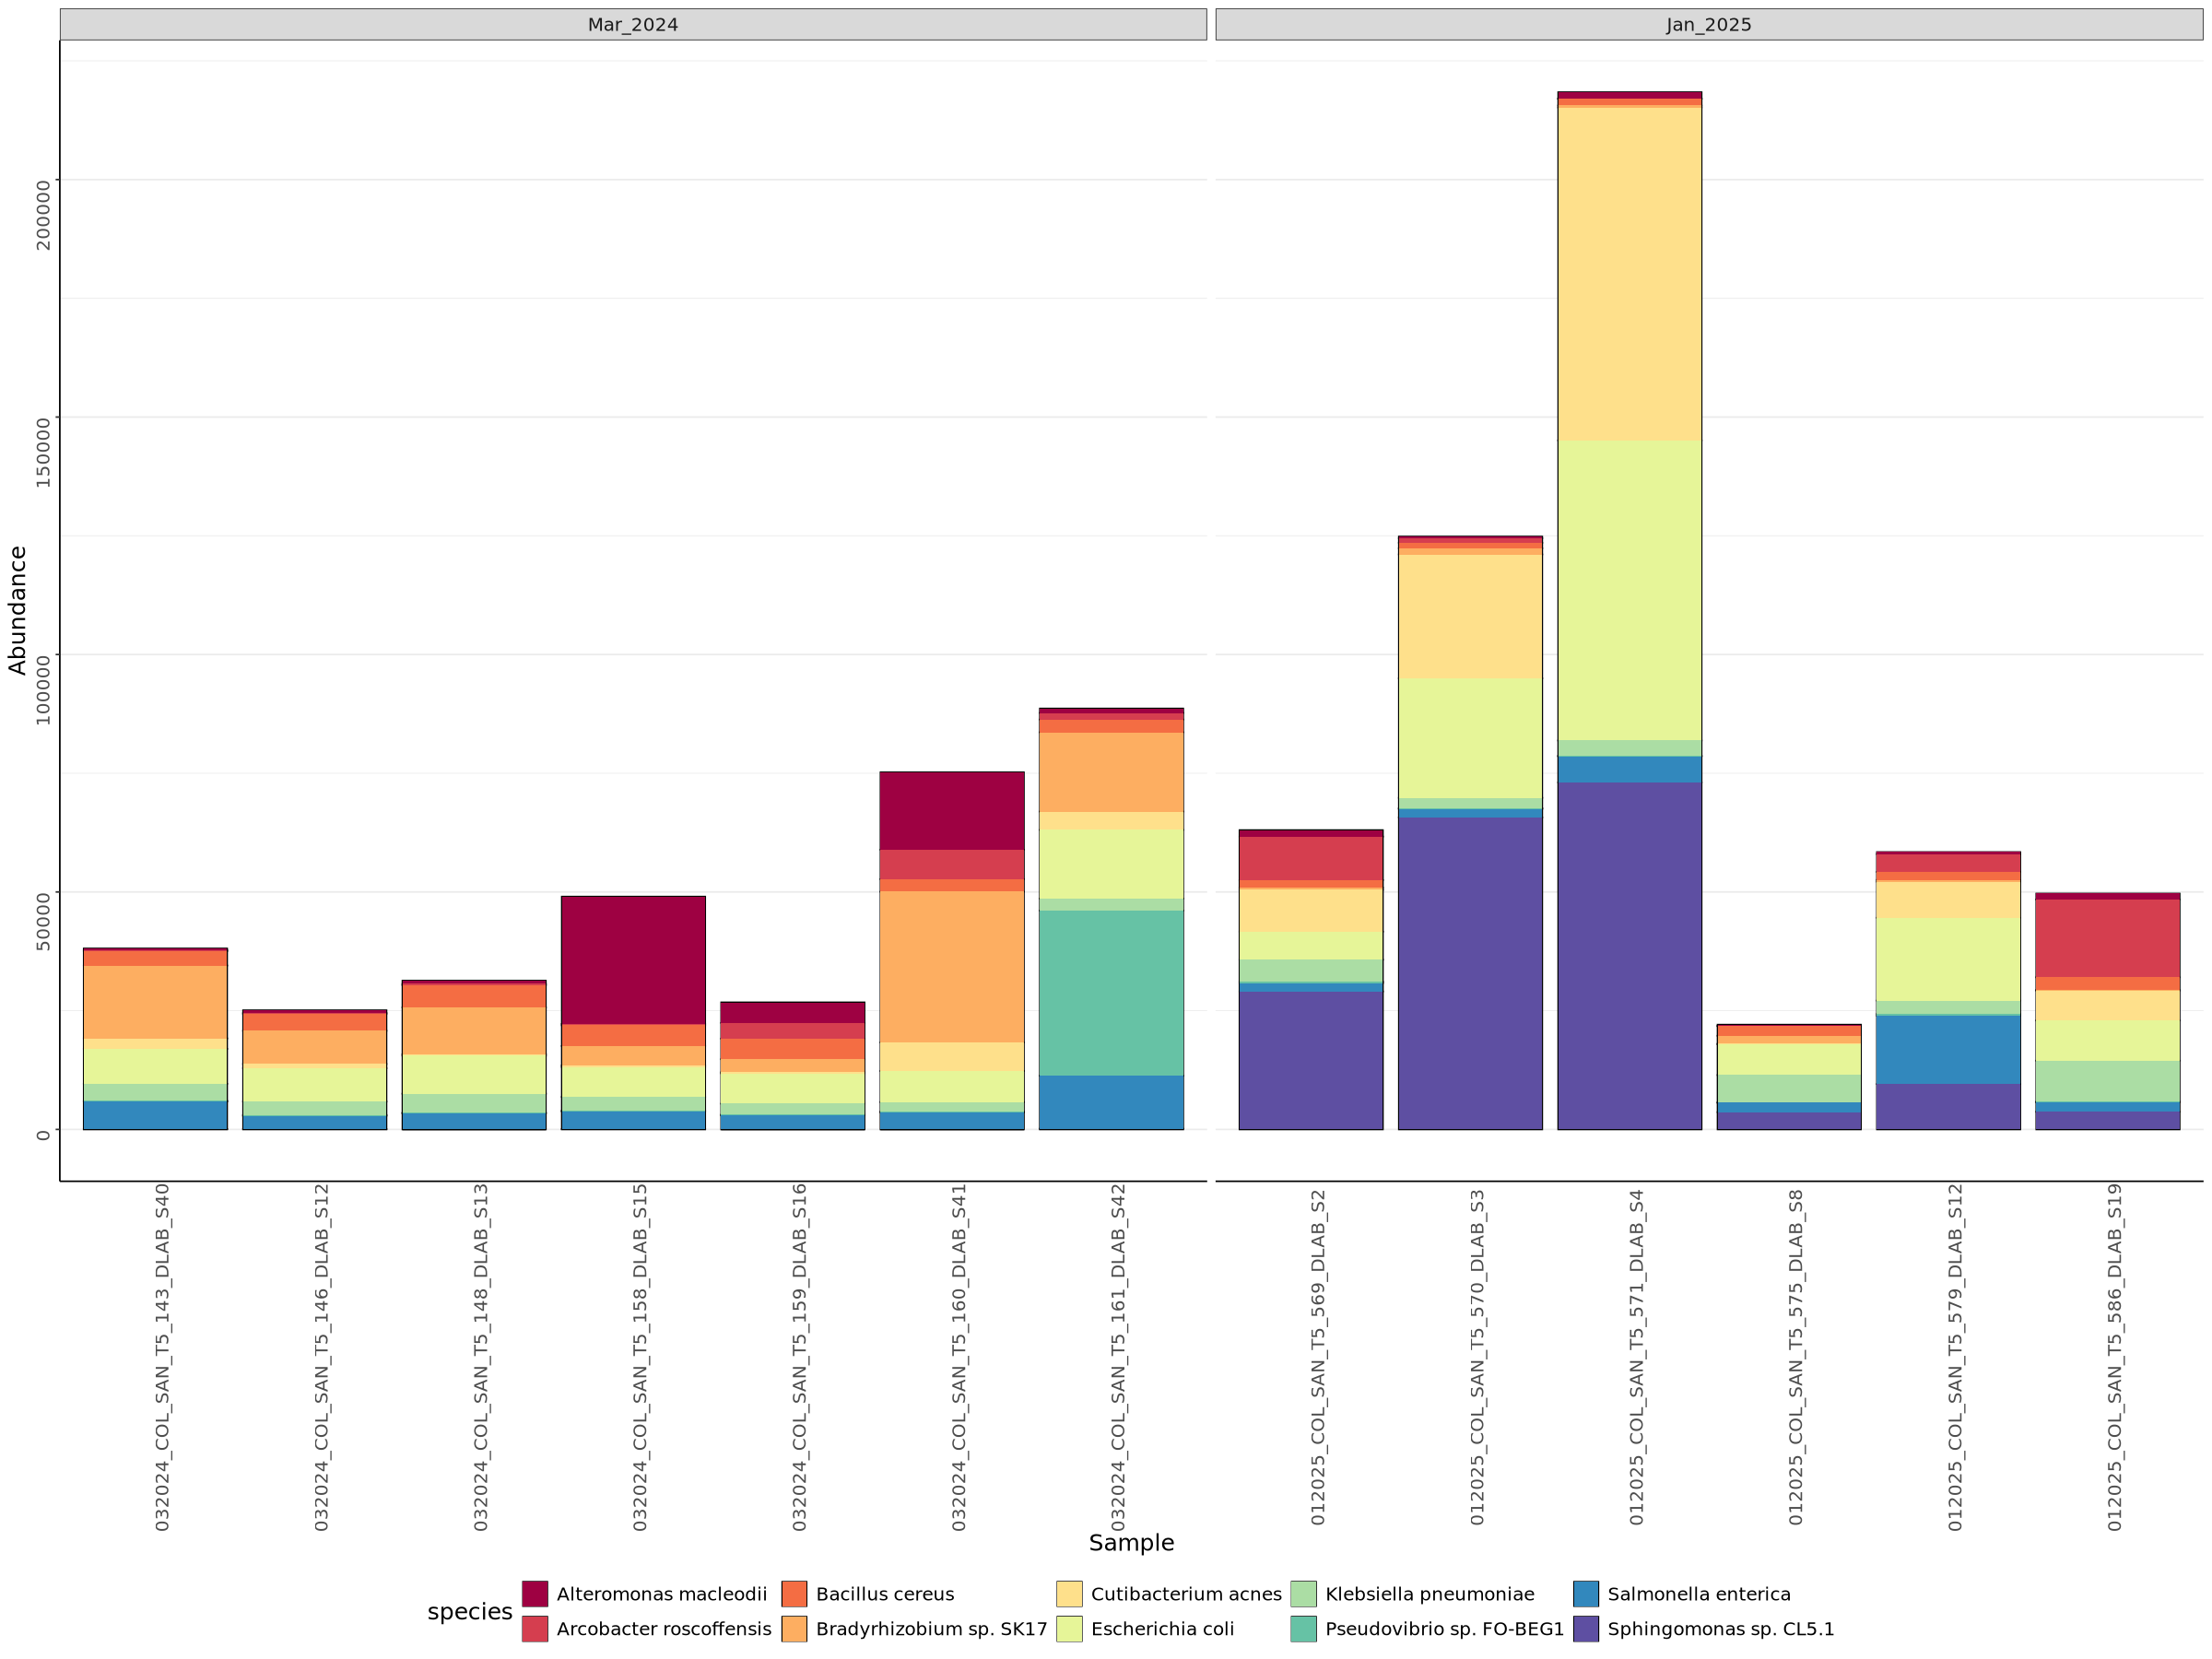

In [91]:
# bar plot of top 10 abundant taxa in MCAV samples
dlab_10_bar<-plot_bar(COL_dlab_10,fill='species')+
facet_grid(~Year_d, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
dlab_10_bar

In [105]:
ggsave(filename = "dlab_top_10_species_bar.png", plot = dlab_10_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

**maybe split up by year? 032024 samples might look different than 012025** 

In [92]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_dlab_24 = read.csv('dlab_032024_otu_normtable_species.csv',header=TRUE)
head(otu_dlab_24)

,X,X032024_COL_SAN_T5_143_DLAB_S40,X032024_COL_SAN_T5_146_DLAB_S12,X032024_COL_SAN_T5_148_DLAB_S13,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,7353.4309,7019.0504,8008.5895,6314.141,6388.731,6552.0784,14466.5859
2,28213,0.0000,0.0000,0.0000,0.000,0.000,0.0000,102.6370
3,573,3610.8400,2832.8215,4018.3168,2870.830,2313.967,1991.2673,2518.7967
4,2721244,810.7740,448.0245,1506.3680,1010.263,1164.775,777.9195,210.5107
5,238834,676.1276,1171.3974,953.4989,1245.991,1172.566,1061.8945,821.0963
6,28901,5808.6168,2814.1538,3385.3217,3725.343,2945.049,3560.8748,11139.2607


In [93]:
# rename first col as otu
names(otu_dlab_24)[1] <- "otu"

#remove X's from headers
names(otu_dlab_24) <- sub("^X", "", names(otu_dlab_24))
otu_table_dlab_24=as.data.frame(otu_dlab_24)

# make the index the otus
row.names(otu_table_dlab_24) <- otu_table_dlab_24$otu
otu_table_dlab_24$otu <- NULL
head(otu_table_dlab_24)

,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,7353.4309,7019.0504,8008.5895,6314.141,6388.731,6552.0784,14466.5859
28213,0.0000,0.0000,0.0000,0.000,0.000,0.0000,102.6370
573,3610.8400,2832.8215,4018.3168,2870.830,2313.967,1991.2673,2518.7967
2721244,810.7740,448.0245,1506.3680,1010.263,1164.775,777.9195,210.5107
238834,676.1276,1171.3974,953.4989,1245.991,1172.566,1061.8945,821.0963
28901,5808.6168,2814.1538,3385.3217,3725.343,2945.049,3560.8748,11139.2607


In [94]:
# sort by most abundant OTUs
otus_sorted_dlab_24 <- otu_table_dlab_24[order(rowSums(otu_table_dlab_24), decreasing = TRUE), ]
head(otus_sorted_dlab_24)

,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,690698.0000,214274.0000,249607.0000,237562.000,256702.0000,581037.0000,954821.0000
2057741,15352.5854,6986.3819,9847.4802,4095.773,2746.3752,31741.5242,16684.8027
562,7353.4309,7019.0504,8008.5895,6314.141,6388.7309,6552.0784,14466.5859
28108,331.5487,550.6968,681.0706,26801.424,4324.0801,16293.2825,933.1592
911045,138.9898,158.6753,120.1889,176.796,163.6138,199.6431,34783.4830
28901,5808.6168,2814.1538,3385.3217,3725.343,2945.0491,3560.8748,11139.2607


In [99]:
#remove total reads row
otus_sorted_dlab_24 <- otus_sorted_dlab_24[-1, ]
head(otus_sorted_dlab_24)
dim (otus_sorted_dlab_24)
# Convert to matrix
otus_dlab_24=as.matrix(otus_sorted_dlab_24)
head(otus_dlab_24)

,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
28108,331.5487,550.6968,681.0706,26801.42447,4324.0801,16293.2825,933.1592
911045,138.9898,158.6753,120.1889,176.79595,163.6138,199.6431,34783.4830
28901,5808.6168,2814.1538,3385.3217,3725.34328,2945.0491,3560.8748,11139.2607
1396,3018.6854,3537.5267,4699.3874,4352.54797,4324.0801,2650.4336,2687.4147
470,2668.3152,4750.9264,3733.8696,3851.62610,3794.2829,2748.5341,2587.9196
1898042,111.4814,144.6746,136.2141,75.76969,148.0316,103.2636,20457.2375


[1] 13365     7

,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42
28108,331.5487,550.6968,681.0706,26801.42447,4324.0801,16293.2825,933.1592
911045,138.9898,158.6753,120.1889,176.79595,163.6138,199.6431,34783.4830
28901,5808.6168,2814.1538,3385.3217,3725.34328,2945.0491,3560.8748,11139.2607
1396,3018.6854,3537.5267,4699.3874,4352.54797,4324.0801,2650.4336,2687.4147
470,2668.3152,4750.9264,3733.8696,3851.62610,3794.2829,2748.5341,2587.9196
1898042,111.4814,144.6746,136.2141,75.76969,148.0316,103.2636,20457.2375


In [97]:
#filter metadata for ofavs only
metadata_dlab_24 <- metadata_dlab[metadata_dlab$Year=="Mar_2024",]
head(metadata_dlab_24)
dim(metadata_dlab_24)

,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_143_DLAB_S40,ELARBOL,3/7/24,Mar_2024,81,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_146_DLAB_S12,ELARBOL,3/7/24,Mar_2024,83,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_148_DLAB_S13,ELARBOL,3/7/24,Mar_2024,86,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_149_DLAB_S14,ELARBOL,3/7/24,Mar_2024,87,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_158_DLAB_S15,ELARBOL,3/7/24,Mar_2024,88,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_159_DLAB_S16,ELARBOL,3/7/24,Mar_2024,94,DLAB,Healthy,Healthy,,,


[1]  8 10

In [100]:
# classify phyloseq objects 
OTU_D_24=otu_table((otus_dlab_24), taxa_are_rows = TRUE)
TAX_D_24=tax_table(taxonomy)
SAMP_D_24=sample_data(metadata_dlab_24)

In [101]:
# Create phyloseq object
COL_dlab_24 = phyloseq(OTU_D_24, SAMP_D_24, TAX_D_24)
COL_dlab_24

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13365 taxa and 7 samples ]
sample_data() Sample Data:       [ 7 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 13365 taxa by 1 taxonomic ranks ]

In [102]:
COL_dlab_24_10 = prune_taxa(names(sort(taxa_sums(COL_dlab_24),TRUE)[1:10]), COL_dlab_24)

In [103]:
#order of facets
sample_data(COL_dlab_24_10)$Year_d <- factor(sample_data(COL_dlab_24_10)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

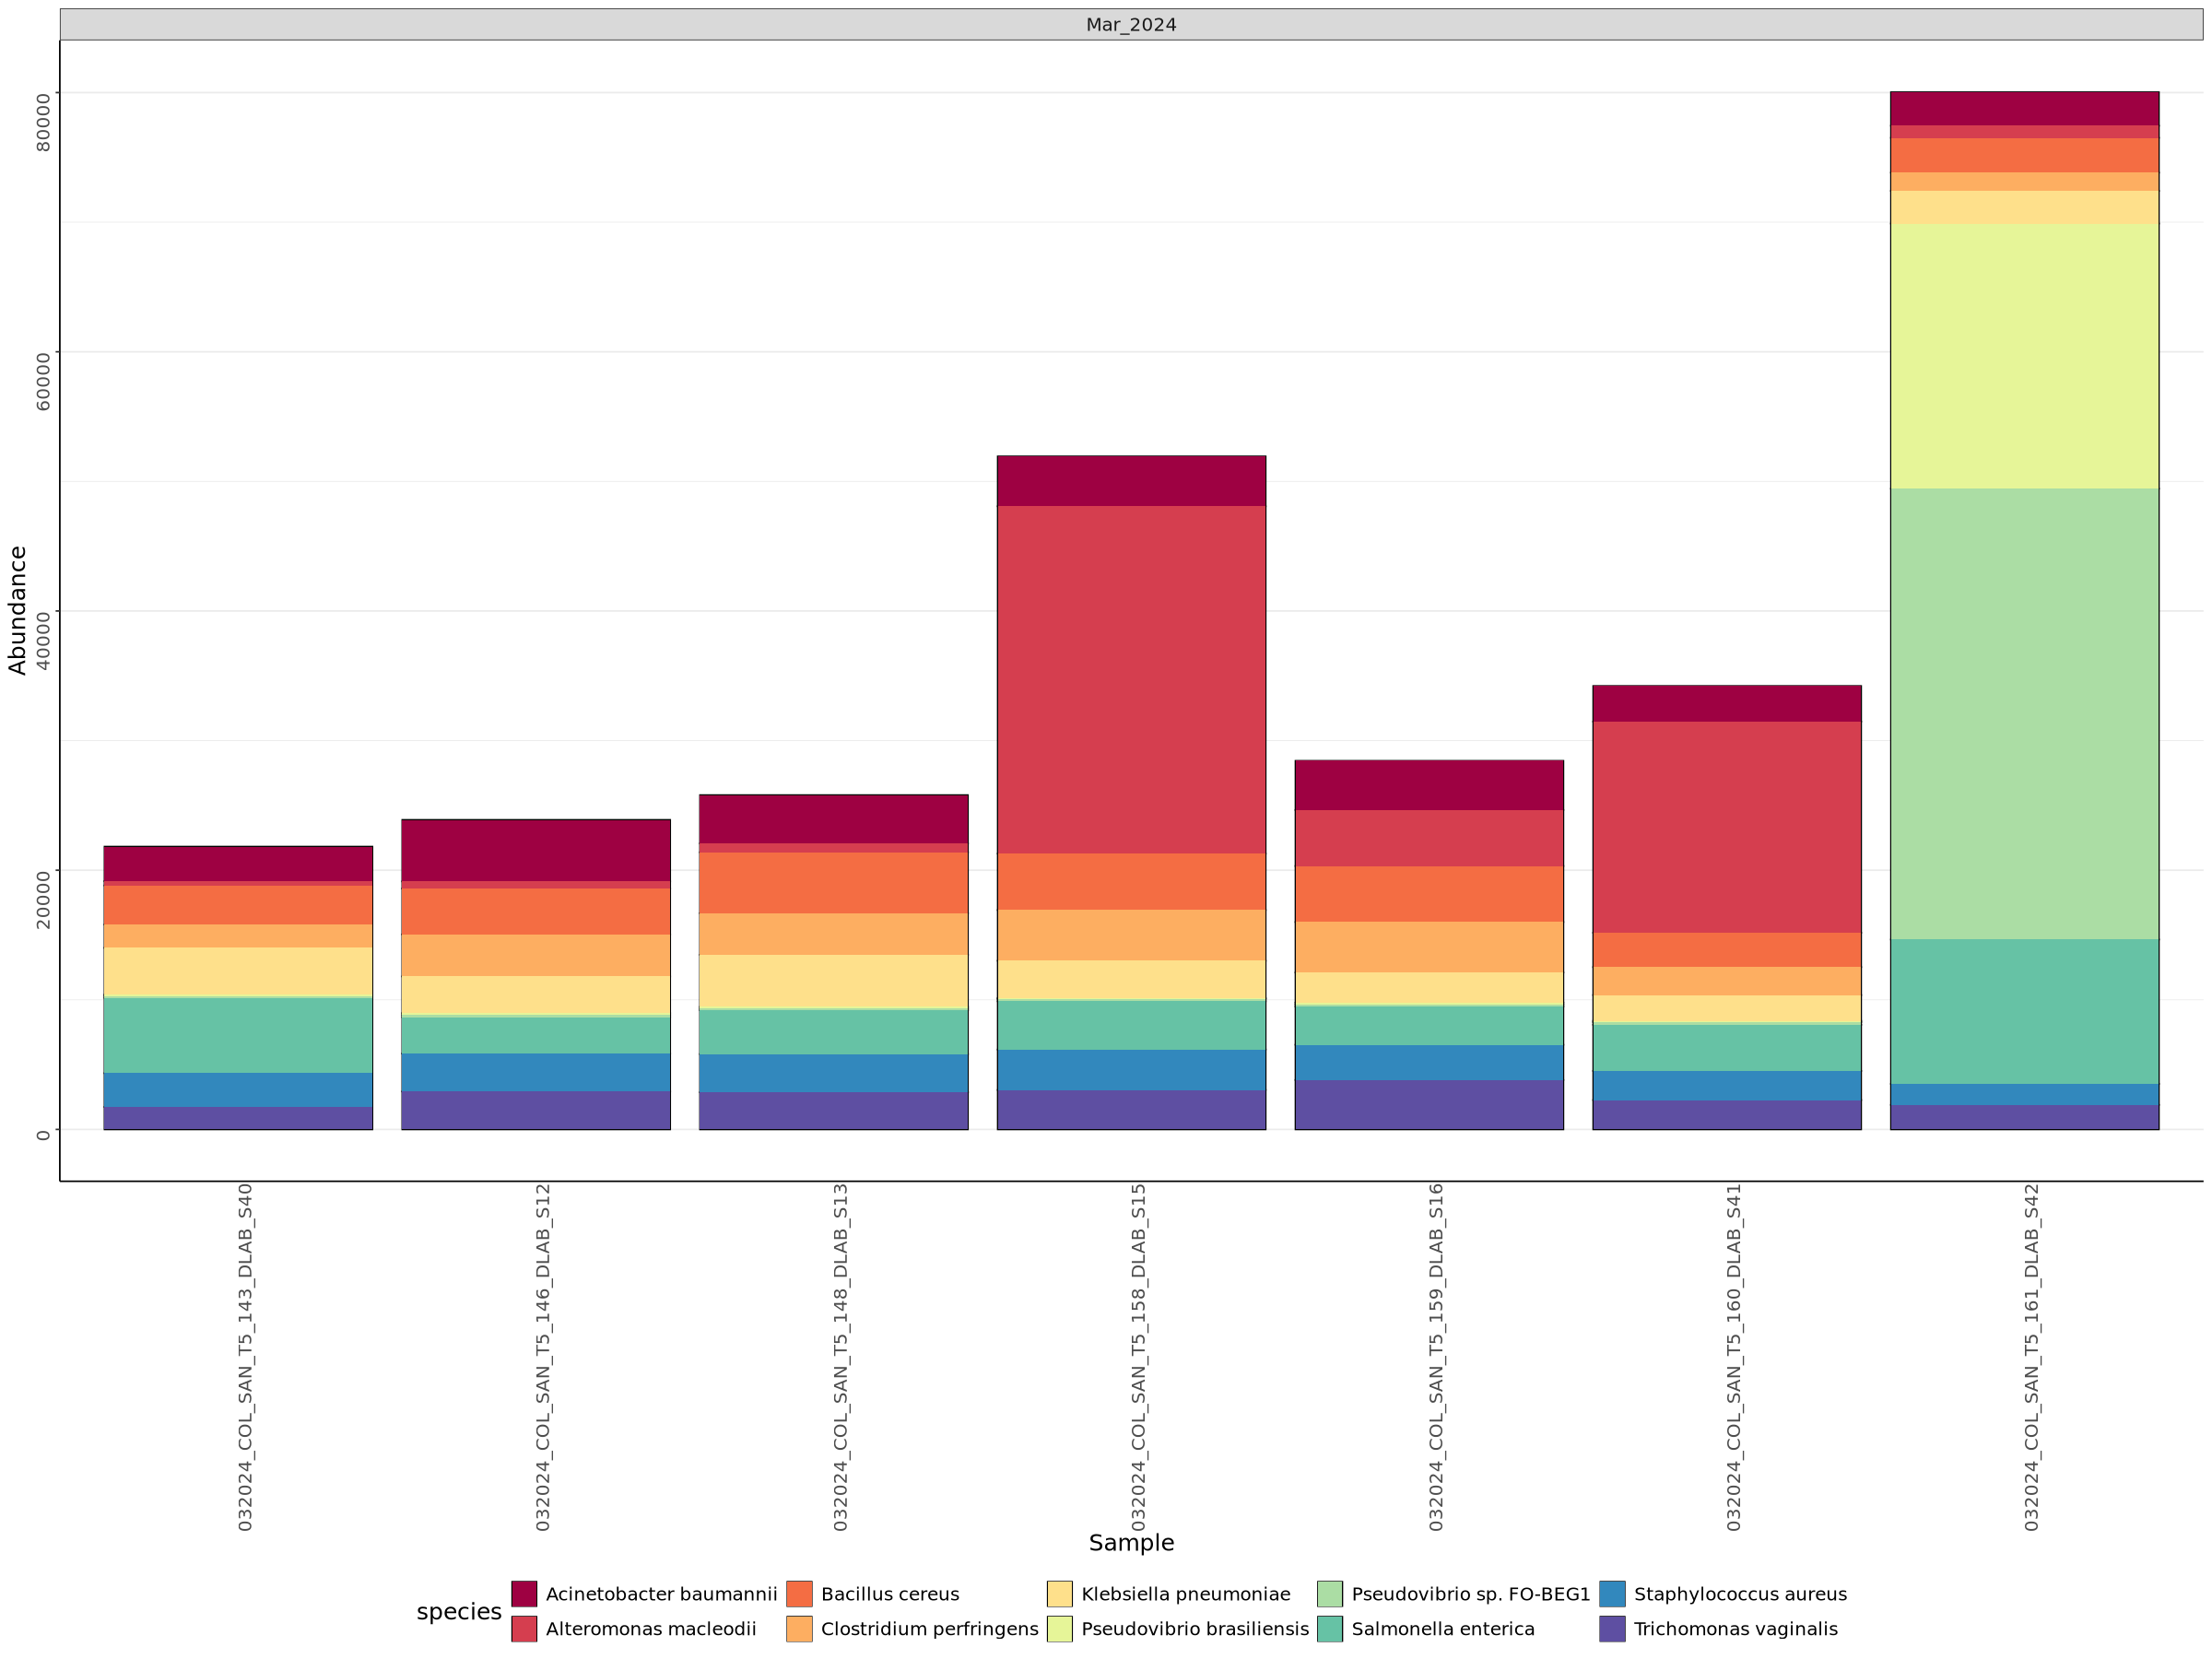

In [104]:
# bar plot of top 10 abundant taxa in MCAV samples
dlab_24_10_bar<-plot_bar(COL_dlab_24_10,fill='species')+
facet_grid(~Year_d, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
dlab_24_10_bar

In [106]:
ggsave(filename = "dlab_032024_top_10_species_bar.png", plot = dlab_24_10_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)